# GPT-2 Source Domain Diagnosis Dataset v9

## Objective

1. **Confirm residualization procedure**: fit on train only, apply to test (no leakage)
2. **LOSO on residualized features**
3. **Counterfactual consistency metric**
4. **Consolidated final table**:
   - 4.1 Source classifier: original vs residualized
   - 4.2 Bias classifier: original vs residualized
   - 4.3 LOSO by source (original + residualized)
   - 4.4 Baseline source-only (predict bias from source majority class) on v9

## 1. Setup and Imports

In [1]:
import subprocess
import sys

try:
    import xgboost  # noqa: F401
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost'])

In [16]:
import json
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GroupShuffleSplit,
    HalvingRandomSearchCV,
    StratifiedGroupKFold,
    cross_validate,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier


def find_root(start: Path, repo_name: str = 'attention-atlas') -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if candidate.name == repo_name:
            return candidate
    return start


_nb_file = Path(globals().get('__vsc_ipynb_file__', '') or '')
if _nb_file.exists():
    root_dir = find_root(_nb_file.parent)
else:
    root_dir = find_root(Path.cwd())
notebook_dir = root_dir / 'dataset'

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f'Root dir: {root_dir}')
print(f'Notebook dir: {notebook_dir}')

Root dir: C:\Users\anoca\Documents\GitHub\attention-atlas
Notebook dir: C:\Users\anoca\Documents\GitHub\attention-atlas\dataset\v2


## 2. Load Dataset v9

In [18]:
dataset_path = notebook_dir / 'bias_sentences_v9.json'
with open(dataset_path, encoding='utf-8') as f:
    raw = json.load(f)

df_sentences = pd.DataFrame(raw['entries'])
df_sentences['label'] = df_sentences['has_bias'].astype(int)

SOURCE_CANONICAL = {
    'biased_corpus_only': 'biased-corpus',
    'biased_corpus_v2': 'biased-corpus',
    'gemini_only': 'gemini',
    'gemini_only_v2': 'gemini',
    'gus_only': 'gus-dataset',
    'gus_only_v2': 'gus-dataset',
}
df_sentences['source_canonical'] = (
    df_sentences['source'].map(SOURCE_CANONICAL).fillna(df_sentences['source'])
)

print(f'Dataset v9: {len(df_sentences)} entries')
print(f'Unique texts: {df_sentences["text"].nunique()} / {len(df_sentences)}')
print(f'Label distribution: {df_sentences["label"].value_counts().sort_index().to_dict()}')
print(f'Sources (canonical): {df_sentences["source_canonical"].value_counts().to_dict()}')
print(f'Roles: {df_sentences["role"].value_counts().to_dict()}')

Dataset v9: 10304 entries
Unique texts: 10304 / 10304
Label distribution: {0: 4807, 1: 5497}
Sources (canonical): {'gemini': 4440, 'biased-corpus': 3235, 'gus-dataset': 2629}
Roles: {'original': 6457, 'counterfactual': 3847}


In [19]:
# Cross-source text overlap
source_groups = df_sentences.groupby('source')['text'].apply(set)
source_names = list(source_groups.index)

print('Cross-source text overlap (should be 0):')
for i in range(len(source_names)):
    for j in range(i + 1, len(source_names)):
        overlap = source_groups[source_names[i]] & source_groups[source_names[j]]
        print(f'  {source_names[i]} vs {source_names[j]}: {len(overlap)}')

print('\nBias by source:')
print(pd.crosstab(df_sentences['source_canonical'], df_sentences['label'], margins=True))

print('\nRole distribution:')
print(pd.crosstab(df_sentences['source_canonical'], df_sentences['role'], margins=True))

Cross-source text overlap (should be 0):
  biased_corpus_only vs gemini_only: 0
  biased_corpus_only vs gus_only: 0
  gemini_only vs gus_only: 0

Bias by source:
label                0     1    All
source_canonical                   
biased-corpus     1169  2066   3235
gemini            2277  2163   4440
gus-dataset       1361  1268   2629
All               4807  5497  10304

Role distribution:
role              counterfactual  original    All
source_canonical                                 
biased-corpus                956      2279   3235
gemini                      2158      2282   4440
gus-dataset                  733      1896   2629
All                         3847      6457  10304


## 3. Load Feature Matrix

In [20]:
features_path = (
    root_dir / 'attention_app' / 'bias' / 'extracted_features'
    / 'feature_matrix_gpt2_v9.pkl'
)
if not features_path.exists():
    raise FileNotFoundError(
        f'Feature matrix not found: {features_path}\n'
        'Run the extraction script first.'
    )

df_features = pd.read_pickle(features_path).copy()
print(f'Feature matrix shape: {df_features.shape[0]} samples x {df_features.shape[1]} columns')

if len(df_features) != len(df_sentences):
    raise RuntimeError(
        f'Size mismatch: feature matrix has {len(df_features)} rows but '
        f'JSON dataset has {len(df_sentences)} rows.'
    )

label_match = np.array_equal(
    df_features['label'].astype(int).values, df_sentences['label'].values
)
print(f'Label alignment with JSON dataset: {label_match}')
if not label_match:
    raise RuntimeError('Feature matrix labels do not align with JSON dataset labels.')

for col in [
    'text', 'source', 'source_canonical', 'original_id',
    'role', 'topic', 'pair_id', 'sentence_id', 'edit_type',
]:
    if col in df_sentences.columns:
        df_features[col] = df_sentences[col].values

print(f'Source distribution: {df_features["source_canonical"].value_counts().to_dict()}')

Feature matrix shape: 10304 samples x 3239 columns
Label alignment with JSON dataset: True
Source distribution: {'gemini': 4440, 'biased-corpus': 3235, 'gus-dataset': 2629}


## 4. Prepare Data

In [21]:
drop_cols = [
    'label', 'id', 'text', 'source', 'source_canonical', 'original_id', 'role',
    'topic', 'pair_id', 'sentence_id', 'type', 'validated_source', 'hasbias',
    'has_bias', 'bias_type', 'bias_description', 'edit_spans', 'edit_type',
]

X = df_features.drop(columns=[c for c in drop_cols if c in df_features.columns])
y = df_features['label'].astype(int)
sources = df_features['source_canonical'].values

group_col = df_features['pair_id'].copy()
mask_no_pair = group_col.isna()
group_col[mask_no_pair] = [
    'unpaired_' + str(i) for i in range(mask_no_pair.sum())
]
groups = group_col.values

print(f'Total features: {X.shape[1]}')
print(f'Total samples:  {X.shape[0]}')
print(f'Unique groups:  {len(set(groups))}')
print(f'Label distribution: biased={int(y.sum())}, neutral={int((y == 0).sum())}')

print('\nSource distribution:')
for src, cnt in Counter(sources).most_common():
    src_labels = y[sources == src]
    print(
        f'  {src:18} {cnt:5d} '
        f'(biased={int(src_labels.sum())}, neutral={int((src_labels == 0).sum())})'
    )

print(f'\nRole distribution: {df_features["role"].value_counts().to_dict()}')

X_final = X.copy()
unique_sources = np.array(sorted(np.unique(sources)))

Total features: 3238
Total samples:  10304
Unique groups:  6460
Label distribution: biased=5497, neutral=4807

Source distribution:
  gemini              4440 (biased=2163, neutral=2277)
  biased-corpus       3235 (biased=2066, neutral=1169)
  gus-dataset         2629 (biased=1268, neutral=1361)

Role distribution: {'original': 6457, 'counterfactual': 3847}


## 4.4. Baseline: Source-Only Prediction on v9

Compute how well one can predict `has_bias` using only the majority class per source.
This is the theoretical ceiling for a source-confounding artefact.

In [7]:
print(' Source-Only Baseline (v9) ')
print('Predict bias label using the majority class of each source.\n')

source_majority = {}
for src in unique_sources:
    src_mask = sources == src
    src_labels = y[src_mask]
    majority = int(src_labels.mode().iloc[0])
    source_majority[src] = majority
    n_correct = int((src_labels == majority).sum())
    n_total = int(src_mask.sum())
    print(
        f'  {src:18} majority={majority}  '
        f'correct={n_correct}/{n_total} ({n_correct/n_total:.1%})'
    )

# Overall source-only accuracy
y_source_baseline = pd.Series(sources).map(source_majority).astype(int).values
source_only_acc = accuracy_score(y, y_source_baseline)
source_only_f1 = f1_score(y, y_source_baseline, zero_division=0)
source_only_auc = roc_auc_score(y, y_source_baseline)

print(f'\nOverall source-only baseline:')
print(f'  Accuracy: {source_only_acc:.4f}')
print(f'  F1:       {source_only_f1:.4f}')
print(f'  AUC:      {source_only_auc:.4f}')
print(f'\nInterpretation: if the model cannot beat {source_only_acc:.1%} accuracy,'
      f' it may just be learning source identity.')

 Source-Only Baseline (v9) 
Predict bias label using the majority class of each source.

  biased-corpus      majority=1  correct=2066/3235 (63.9%)
  gemini             majority=0  correct=2277/4440 (51.3%)
  gus-dataset        majority=0  correct=1361/2629 (51.8%)

Overall source-only baseline:
  Accuracy: 0.5536
  F1:       0.4732
  AUC:      0.5663

Interpretation: if the model cannot beat 55.4% accuracy, it may just be learning source identity.


## 5. LOSO-Gemini Error Profile

In [10]:
import re
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier
# 1) Rebuild Gemini LOSO fold and predictions
test_source = "gemini"
test_mask = sources == test_source
train_mask = ~test_mask
X_train_l = X_final.iloc[np.where(train_mask)[0]]
X_test_l = X_final.iloc[np.where(test_mask)[0]]
y_train_l = y.iloc[np.where(train_mask)[0]]
y_test_l = y.iloc[np.where(test_mask)[0]]
gemini_loso_model = Pipeline([
    ("vt", VarianceThreshold(threshold=0.01)),
    ("s", StandardScaler()),
    ("m", XGBClassifier(
        tree_method="approx",
        max_depth=8,
        n_estimators=500,
        learning_rate=0.05,
        min_child_weight=1,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1.0,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
    )),
])
gemini_loso_model.fit(X_train_l, y_train_l)
y_pred = gemini_loso_model.predict(X_test_l)
y_prob = gemini_loso_model.predict_proba(X_test_l)[:, 1]
idx_test = np.where(test_mask)[0]
df_eval = df_features.iloc[idx_test].copy()
df_eval["y_true"] = y_test_l.values
df_eval["y_pred"] = y_pred
df_eval["p_bias"] = y_prob
df_eval["is_error"] = df_eval["y_true"] != df_eval["y_pred"]
df_eval["error_type"] = np.where(
    (df_eval["y_true"] == 0) & (df_eval["y_pred"] == 1), "FP",
    np.where((df_eval["y_true"] == 1) & (df_eval["y_pred"] == 0), "FN", "OK")
)
# 2) Add linguistic/style features
hedge_pattern = re.compile(
    r"\b("
    r"maybe|perhaps|possibly|probably|likely|seems?|appears?|tends?\s+to|"
    r"i\s+think|i\s+guess|it\s+seems|it\s+appears|some|often|sometimes|generally|"
    r"talvez|possivelmente|provavelmente|parece|acho\s+que|em\s+geral|às\s+vezes|as\s+vezes"
    r")\b",
    flags=re.IGNORECASE
)
generalization_pattern = re.compile(
    r"\b(all|always|never|every|everyone|nobody|none|anyone|men|women|boys|girls|"
    r"todos|todas|sempre|nunca|ninguem|ninguém|homens|mulheres)\b",
    flags=re.IGNORECASE
)
df_eval["text"] = df_eval["text"].fillna("")
df_eval["topic"] = df_eval["topic"].fillna("unknown")
df_eval["n_tokens"] = df_eval["text"].str.split().str.len()
df_eval["is_question"] = df_eval["text"].str.contains(r"\?")
df_eval["has_hedge"] = df_eval["text"].str.contains(hedge_pattern)
df_eval["has_generalization"] = df_eval["text"].str.contains(generalization_pattern)
def formulation_type(row):
    if row["is_question"] and row["has_hedge"]:
        return "question+hedge"
    if row["is_question"]:
        return "question"
    if row["has_hedge"]:
        return "hedged statement"
    if row["has_generalization"]:
        return "explicit generalization"
    return "plain statement"
df_eval["formulation_type"] = df_eval.apply(formulation_type, axis=1)
# 3) Separate FP and FN + group errors
df_err = df_eval[df_eval["is_error"]].copy()
bins = [0, 8, 14, 22, np.inf]
labels = ["short (<=8)", "medium (9-14)", "long (15-22)", "very long (23+)"]
df_err["length_bin"] = pd.cut(df_err["n_tokens"], bins=bins, labels=labels, right=True)
len_table = df_err.groupby(["error_type", "length_bin"], observed=False).size().unstack(fill_value=0)
topic_table = (
    df_err.groupby(["error_type", "topic"])
    .size()
    .reset_index(name="n_errors")
    .sort_values(["error_type", "n_errors"], ascending=[True, False])
)
top_topics = topic_table.groupby("error_type").head(12)
form_table = df_err.groupby(["error_type", "formulation_type"]).size().unstack(fill_value=0)
flag_rates = (
    df_err.groupby("error_type")[["is_question", "has_hedge", "has_generalization"]]
    .mean()
    .rename(columns={
        "is_question": "question_rate",
        "has_hedge": "hedge_rate",
        "has_generalization": "generalization_rate",
    })
)
# 4) Pick 4 representative examples: 2 FP + 2 FN
train_topics = (
    df_features.iloc[np.where(train_mask)[0]]["topic"]
    .fillna("unknown")
    .value_counts()
    .to_dict()
)
def interpret_error(row):
    topic_seen = train_topics.get(row["topic"], 0)
    if row["error_type"] == "FP":
        if row["is_question"]:
            return "style error: factual question flagged as bias"
        if row["has_hedge"]:
            return "style error: cautious wording over-penalized"
        if topic_seen == 0:
            return "domain transfer error: unseen topic in training"
        return "lexical trigger without true bias"
    else:  # FN
        if row["has_hedge"]:
            return "hedging too subtle for the model"
        if (not row["has_generalization"]) and (not row["is_question"]):
            return "bias too implicit (low lexical salience)"
        if topic_seen == 0:
            return "domain transfer error: weak topic transfer"
        return "implicit stereotype missed"
def pick_examples(err_df, err_type, n=2):
    d = err_df[err_df["error_type"] == err_type].copy()
    if d.empty:
        return d
    picks = []
    if err_type == "FP":
        c1 = d[d["is_question"]].sort_values("p_bias", ascending=False).head(1)
        c2 = d[d["has_hedge"] & ~d.index.isin(c1.index)].sort_values("p_bias", ascending=False).head(1)
    else:
        c1 = d[d["has_hedge"]].sort_values("p_bias", ascending=True).head(1)
        c2 = d[(~d["has_generalization"]) & (~d["is_question"]) & ~d.index.isin(c1.index)].sort_values("p_bias", ascending=True).head(1)
    picks.extend([c1, c2])
    out = pd.concat([x for x in picks if len(x) > 0], axis=0)
    if len(out) < n:
        remaining = d[~d.index.isin(out.index)]
        out = pd.concat([out, remaining.head(n - len(out))], axis=0)
    return out.head(n)
fp_examples = pick_examples(df_err, "FP", 2)
fn_examples = pick_examples(df_err, "FN", 2)
examples = pd.concat([fp_examples, fn_examples], axis=0).copy()
examples["interpretation"] = examples.apply(interpret_error, axis=1)
# 5) Print concise report
cm = confusion_matrix(df_eval["y_true"], df_eval["y_pred"])
n_fp = int((df_eval["error_type"] == "FP").sum())
n_fn = int((df_eval["error_type"] == "FN").sum())
print("=== Gemini LOSO Error Analysis ===")
print("Confusion matrix [rows=true, cols=pred]:")
print(cm)
print(f"\nTotal test samples: {len(df_eval)}")
print(f"Errors: {int(df_eval['is_error'].sum())} ({df_eval['is_error'].mean():.1%}) | FP={n_fp} | FN={n_fn}")
print("\n=== Errors by sentence length ===")
print(len_table)
print("\n=== Errors by topic (top 12 per error type) ===")
print(top_topics.to_string(index=False))
print("\n=== Errors by formulation type ===")
print(form_table)
print("\n=== Linguistic marker rates within errors ===")
print((100 * flag_rates).round(1).astype(str) + "%")
print("\n=== 4 Representative Examples (2 FP + 2 FN) ===")
for i, r in examples.reset_index(drop=True).iterrows():
    print(f"\n[{i+1}] {r['error_type']} | true={r['y_true']} pred={r['y_pred']} p_bias={r['p_bias']:.3f}")
    print(f"topic={r['topic']} | n_tokens={int(r['n_tokens'])} | formulation={r['formulation_type']}")
    print(f"text: {r['text']}")
    print(f"interpretation: {r['interpretation']}")

=== Gemini LOSO Error Analysis ===
Confusion matrix [rows=true, cols=pred]:
[[1612  665]
 [ 894 1269]]

Total test samples: 4440
Errors: 1559 (35.1%) | FP=665 | FN=894

=== Errors by sentence length ===
length_bin  short (<=8)  medium (9-14)  long (15-22)  very long (23+)
error_type                                                           
FN                  105            560           218               11
FP                  567             73            25                0

=== Errors by topic (top 12 per error type) ===
error_type       topic  n_errors
        FN     general       217
        FN    everyday       187
        FN     economy        80
        FN      health        73
        FN         law        62
        FN  technology        51
        FN   education        49
        FN     culture        48
        FN    politics        48
        FN     science        33
        FN environment        32
        FN       other        12
        FP     general       150
      

## 6. Source Classifier (Original Features)

In [11]:
le = LabelEncoder()
y_source = le.fit_transform(sources)

print(f'Source labels: {list(le.classes_)}')
print(f'Random baseline: {1 / len(le.classes_):.1%}')

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
train_idx_src, test_idx_src = next(gss.split(X_final, y_source, groups=groups))

X_train_src = X_final.iloc[train_idx_src]
X_test_src = X_final.iloc[test_idx_src]
y_train_src = y_source[train_idx_src]
y_test_src = y_source[test_idx_src]
groups_train_src = groups[train_idx_src]

print(f'Train: {len(X_train_src)} | Test: {len(X_test_src)}')

src_models = {
    'LogReg': LogisticRegression(solver='lbfgs', max_iter=1000),
    'XGBoost': XGBClassifier(
        tree_method='approx', max_depth=8, n_estimators=500,
        learning_rate=0.05, eval_metric='mlogloss', random_state=RANDOM_STATE,
    ),
}

cv_src = StratifiedGroupKFold(n_splits=5)
best_src_acc = -1
best_src_name = None

for name, model in src_models.items():
    src_pipe = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', model),
    ])
    cv_scores = cross_validate(
        src_pipe, X_train_src, y_train_src,
        cv=cv_src, scoring='accuracy', groups=groups_train_src,
    )
    print(f'  {name:12} CV Acc: {cv_scores["test_score"].mean():.4f}')

    src_pipe.fit(X_train_src, y_train_src)
    y_pred_src = src_pipe.predict(X_test_src)
    acc = accuracy_score(y_test_src, y_pred_src)
    print(f'  {name:12} Test Acc: {acc:.4f}')

    if acc > best_src_acc:
        best_src_acc = acc
        best_src_name = name

print(f'\nBest source classifier: {best_src_name} â€” Test Accuracy: {best_src_acc:.4f}')
print(f'Random baseline: {1 / len(le.classes_):.4f}')

Source labels: ['biased-corpus', 'gemini', 'gus-dataset']
Random baseline: 33.3%
Train: 8232 | Test: 2072
  LogReg       CV Acc: 0.6904
  LogReg       Test Acc: 0.6892
  XGBoost      CV Acc: 0.6906
  XGBoost      Test Acc: 0.6791

Best source classifier: LogReg â€” Test Accuracy: 0.6892
Random baseline: 0.3333


## 7.1. Counterfactual Consistency (Point 3)

In [16]:
print('Counterfactual Consistency Analysis')
print('=' * 60)

paired_entries = df_features[df_features['pair_id'].notna()].copy()
pair_groups = paired_entries.groupby('pair_id')

test_idx_set = set(test_idx)
results_cc = []

for pid, group in pair_groups:
    orig = group[group['role'] == 'original']
    cf = group[group['role'] == 'counterfactual']
    if len(orig) != 1 or len(cf) != 1:
        continue

    orig_pos = orig.index[0]
    cf_pos = cf.index[0]

    X_orig = X_final.iloc[[orig_pos]]
    X_cf = X_final.iloc[[cf_pos]]

    pred_orig = final_model.predict(X_orig)[0]
    pred_cf = final_model.predict(X_cf)[0]
    prob_orig = final_model.predict_proba(X_orig)[0, 1]
    prob_cf = final_model.predict_proba(X_cf)[0, 1]

    label_orig = int(y.iloc[orig_pos])
    label_cf = int(y.iloc[cf_pos])

    orig_correct = (pred_orig == label_orig)
    cf_correct = (pred_cf == label_cf)
    both_correct = orig_correct and cf_correct

    if label_orig > label_cf:
        direction_correct = prob_orig > prob_cf
    elif label_orig < label_cf:
        direction_correct = prob_cf > prob_orig
    else:
        direction_correct = True

    prob_delta = abs(prob_orig - prob_cf)
    is_held_out = orig_pos in test_idx_set

    results_cc.append({
        'pair_id': pid,
        'text_orig': orig['text'].values[0][:80],
        'text_cf': cf['text'].values[0][:80],
        'label_orig': label_orig,
        'label_cf': label_cf,
        'pred_orig': pred_orig,
        'pred_cf': pred_cf,
        'prob_orig': prob_orig,
        'prob_cf': prob_cf,
        'prob_delta': prob_delta,
        'orig_correct': orig_correct,
        'cf_correct': cf_correct,
        'both_correct': both_correct,
        'direction_correct': direction_correct,
        'source': orig['source_canonical'].values[0],
        'is_held_out': is_held_out,
    })

df_cc = pd.DataFrame(results_cc)
df_cc_heldout = df_cc[df_cc['is_held_out']]

print(f'\nTotal pairs evaluated: {len(df_cc)}')
print(f'Held-out pairs (original in test): {len(df_cc_heldout)}')

for label, subset in [('ALL PAIRS', df_cc), ('HELD-OUT PAIRS ONLY', df_cc_heldout)]:
    if len(subset) == 0:
        continue
    print(f'\n {label} ({len(subset)} pairs) ')
    print(f'  Full consistency (both correct): {subset["both_correct"].mean():.1%}')
    print(f'  Original correct:                {subset["orig_correct"].mean():.1%}')
    print(f'  CF correct:                      {subset["cf_correct"].mean():.1%}')
    print(f'  Direction correct:               {subset["direction_correct"].mean():.1%}')
    print(f'  Mean |P(orig) - P(cf)|:          {subset["prob_delta"].mean():.3f}')

print(f'\n Consistency by Source ')
for src in df_cc['source'].unique():
    sub = df_cc[df_cc['source'] == src]
    print(
        f'  {src:18s}: consistency={sub["both_correct"].mean():.1%}  '
        f'direction={sub["direction_correct"].mean():.1%}  n={len(sub)}'
    )

Counterfactual Consistency Analysis

Total pairs evaluated: 3844
Held-out pairs (original in test): 790

 ALL PAIRS (3844 pairs) 
  Full consistency (both correct): 81.7%
  Original correct:                92.0%
  CF correct:                      89.4%
  Direction correct:               98.4%
  Mean |P(orig) - P(cf)|:          0.682

 HELD-OUT PAIRS ONLY (790 pairs) 
  Full consistency (both correct): 75.8%
  Original correct:                89.4%
  CF correct:                      86.1%
  Direction correct:               97.2%
  Mean |P(orig) - P(cf)|:          0.664

 Consistency by Source 
  gemini            : consistency=87.2%  direction=99.2%  n=2156
  gus-dataset       : consistency=73.1%  direction=97.1%  n=731
  biased-corpus     : consistency=75.8%  direction=97.5%  n=957


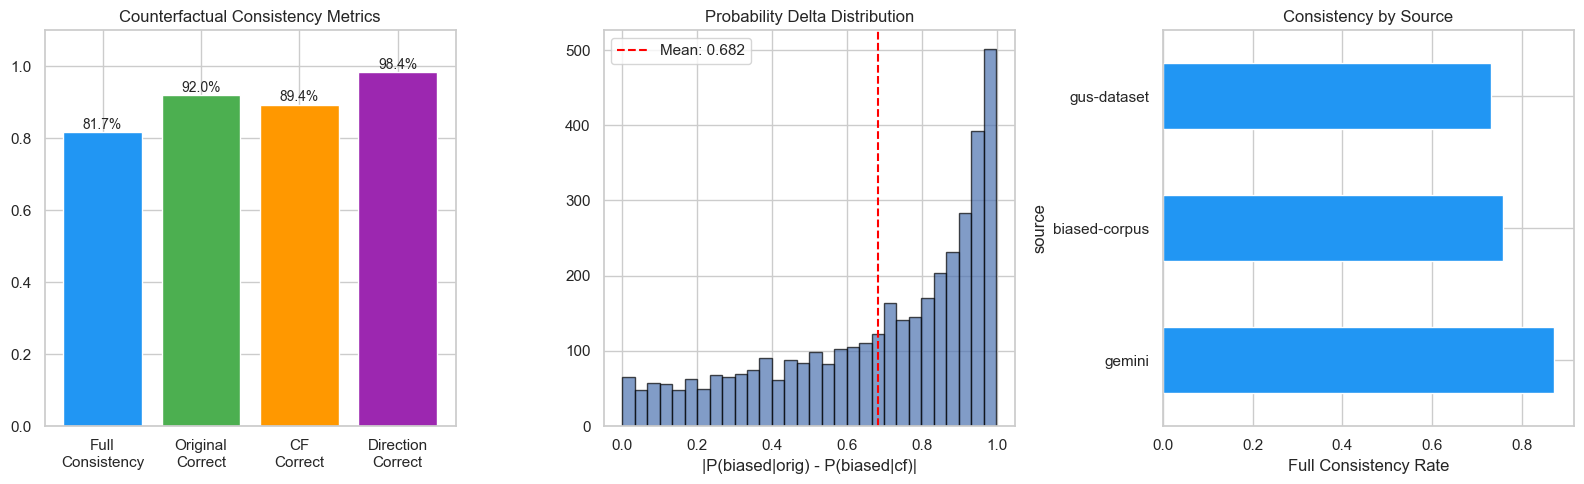

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics_cc = ['both_correct', 'orig_correct', 'cf_correct', 'direction_correct']
labels_cc = ['Full\nConsistency', 'Original\nCorrect', 'CF\nCorrect', 'Direction\nCorrect']
vals_cc = [df_cc[m].mean() for m in metrics_cc]
bars = axes[0].bar(labels_cc, vals_cc, color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'])
for bar, v in zip(bars, vals_cc):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{v:.1%}', ha='center', fontsize=10)
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Counterfactual Consistency Metrics')

axes[1].hist(df_cc['prob_delta'], bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(df_cc['prob_delta'].mean(), color='red', linestyle='--',
                label=f'Mean: {df_cc["prob_delta"].mean():.3f}')
axes[1].set_xlabel('|P(biased|orig) - P(biased|cf)|')
axes[1].set_title('Probability Delta Distribution')
axes[1].legend()

src_consistency = df_cc.groupby('source')['both_correct'].mean().sort_values(ascending=False)
src_consistency.plot(kind='barh', ax=axes[2], color='#2196F3')
axes[2].set_xlabel('Full Consistency Rate')
axes[2].set_title('Consistency by Source')

plt.tight_layout()
plt.show()

## 10. Consolidated Final Table (Point 4)

All results in one place:
- 4.1 Source classifier: original vs residualized
- 4.2 Bias classifier: original vs residualized
- 4.3 LOSO by source (original + residualized)
- 4.4 Source-only baseline on v9

In [25]:
print('=' * 80)
print('CONSOLIDATED RESULTS TABLE â€” Dataset v9')
print('=' * 80)

#  4.4 Source-Only Baseline 
print('\n 4.4 Source-Only Baseline (v9) ')
print(f'  Accuracy: {source_only_acc:.4f}')
print(f'  F1:       {source_only_f1:.4f}')
print(f'  AUC:      {source_only_auc:.4f}')

#  4.1 Source Classifier 
print('\n 4.1 Source Classifier (Original vs Residualized) ')
print(f'{"":18} {"Accuracy":>10}')
print(f'{"Original features":18} {best_src_acc:10.4f}')
print(f'{"Residualized":18} {src_acc_residual:10.4f}')
print(f'{"Random baseline":18} {1/len(unique_sources):10.4f}')

#  4.2 Bias Classifier 
print('\n 4.2 Bias Classifier (Original vs Residualized) ')
print(f'{"Metric":12} | {"Original":>10} | {"Residualized":>12} | {"Delta":>8}')
print('-' * 52)
for metric, vo, vr in [
    ('AUC', orig_auc, auc_res),
    ('Accuracy', orig_acc, acc_res),
    ('Precision', orig_prec, prec_res),
    ('Recall', orig_rec, rec_res),
    ('F1', orig_f1, f1_res),
]:
    print(f'{metric:12} | {vo:10.4f} | {vr:12.4f} | {vr - vo:+8.4f}')

#  4.3 LOSO by Source 
print('\n 4.3 LOSO by Source (Original vs Residualized) ')
print(f'{"Source":18} | {"Orig AUC":>9} | {"Resid AUC":>10} | '
      f'{"Orig F1":>8} | {"Resid F1":>9} | {"Delta AUC":>10}')
print('-' * 80)
for _, row_o in df_loso.iterrows():
    src = row_o['test_source']
    row_r = df_loso_resid[df_loso_resid['test_source'] == src].iloc[0]
    print(
        f'{src:18} | {row_o["auc"]:9.4f} | {row_r["auc"]:10.4f} | '
        f'{row_o["f1"]:8.4f} | {row_r["f1"]:9.4f} | {row_r["auc"] - row_o["auc"]:+10.4f}'
    )
print('-' * 80)
print(
    f'{"MEAN":18} | {df_loso["auc"].mean():9.4f} | {df_loso_resid["auc"].mean():10.4f} | '
    f'{df_loso["f1"].mean():8.4f} | {df_loso_resid["f1"].mean():9.4f} | '
    f'{df_loso_resid["auc"].mean() - df_loso["auc"].mean():+10.4f}'
)

#  Counterfactual Consistency Summary 
print('\n Counterfactual Consistency (Point 3) ')
print(f'  Total pairs:             {len(df_cc)}')
print(f'  Held-out pairs:          {len(df_cc_heldout)}')
if len(df_cc_heldout) > 0:
    print(f'  Full consistency (held-out):  {df_cc_heldout["both_correct"].mean():.1%}')
    print(f'  Direction correct (held-out): {df_cc_heldout["direction_correct"].mean():.1%}')
print(f'  Full consistency (all):       {df_cc["both_correct"].mean():.1%}')
print(f'  Direction correct (all):      {df_cc["direction_correct"].mean():.1%}')
print(f'  Mean prob delta (all):        {df_cc["prob_delta"].mean():.3f}')

CONSOLIDATED RESULTS TABLE â€” Dataset v9

 4.4 Source-Only Baseline (v9) 
  Accuracy: 0.5536
  F1:       0.4732
  AUC:      0.5663

 4.1 Source Classifier (Original vs Residualized) 
                     Accuracy
Original features      0.6892
Residualized           0.3711
Random baseline        0.3333

 4.2 Bias Classifier (Original vs Residualized) 
Metric       |   Original | Residualized |    Delta
----------------------------------------------------
AUC          |     0.9603 |       0.9671 |  +0.0068
Accuracy     |     0.8830 |       0.8986 |  +0.0156
Precision    |     0.8531 |       0.8618 |  +0.0087
Recall       |     0.8780 |       0.9089 |  +0.0310
F1           |     0.8654 |       0.8848 |  +0.0194

 4.3 LOSO by Source (Original vs Residualized) 
Source             |  Orig AUC |  Resid AUC |  Orig F1 |  Resid F1 |  Delta AUC
--------------------------------------------------------------------------------
biased-corpus      |    0.8569 |     0.8399 |   0.8343 |    0.8213 |   

In [26]:
#  Interpretation 
delta_auc_bias = auc_res - orig_auc
delta_f1_bias = f1_res - orig_f1

print('=' * 80)
print('INTERPRETATION')
print('=' * 80)

print(f'\n1. SOURCE CONFOUNDING')
print(f'   Source-only baseline accuracy on v9: {source_only_acc:.1%}')
print(f'   (v5 reference was ~54.4%)')
print(f'   Source classifier on original features: {best_src_acc:.1%}')
print(f'   Source classifier after residualization: {src_acc_residual:.1%}')
print(f'   => Residualization removes the linear source component.')

print(f'\n2. BIAS SIGNAL ROBUSTNESS')
if abs(delta_auc_bias) < 0.05 and abs(delta_f1_bias) < 0.05:
    print('   Bias classifier is STABLE after residualization.')
    print('   The bias signal persists after removing the linear source component.')
elif delta_auc_bias < -0.05 or delta_f1_bias < -0.05:
    print('   Bias classifier DROPS after residualization.')
    print('   The model was partially relying on source artifacts.')
else:
    print('   Bias classifier IMPROVES after residualization.')
    print('   Source information was acting as noise.')

print(f'\n3. LOSO GENERALIZATION')
print(f'   Mean LOSO AUC (original):      {df_loso["auc"].mean():.4f}')
print(f'   Mean LOSO AUC (residualized):  {df_loso_resid["auc"].mean():.4f}')
weakest = df_loso_resid.loc[df_loso_resid['auc'].idxmin()]
print(f'   Weakest LOSO fold: {weakest["test_source"]} (AUC={weakest["auc"]:.4f})')
print(f'   => Non-linear domain effects likely still present for this source.')

print(f'\n4. RESIDUALIZATION PROCEDURE (Point 1 â€” confirmed)')
print(f'   LinearRegression fitted on TRAIN indices only ({len(train_idx)} samples).')
print(f'   Coefficients applied to both train and test.')
print(f'   LOSO residualization re-fitted per fold (train sources only).')
print(f'   => No leakage from test set source distributions.')

INTERPRETATION

1. SOURCE CONFOUNDING
   Source-only baseline accuracy on v9: 55.4%
   (v5 reference was ~54.4%)
   Source classifier on original features: 68.9%
   Source classifier after residualization: 37.1%
   => Residualization removes the linear source component.

2. BIAS SIGNAL ROBUSTNESS
   Bias classifier is STABLE after residualization.
   The bias signal persists after removing the linear source component.

3. LOSO GENERALIZATION
   Mean LOSO AUC (original):      0.7921
   Mean LOSO AUC (residualized):  0.7615
   Weakest LOSO fold: gus-dataset (AUC=0.7179)
   => Non-linear domain effects likely still present for this source.

4. RESIDUALIZATION PROCEDURE (Point 1 â€” confirmed)
   LinearRegression fitted on TRAIN indices only (8229 samples).
   Coefficients applied to both train and test.
   LOSO residualization re-fitted per fold (train sources only).
   => No leakage from test set source distributions.


In [27]:
from IPython.display import display

rows = []

rows.append(('4.1 Source Classifier', 'Accuracy', f'{best_src_acc:.4f}', f'{src_acc_residual:.4f}'))
rows.append(('', 'Random baseline', f'{1/len(unique_sources):.4f}', ''))

for metric, vo, vr in [
    ('AUC', orig_auc, auc_res),
    ('Accuracy', orig_acc, acc_res),
    ('Precision', orig_prec, prec_res),
    ('Recall', orig_rec, rec_res),
    ('F1', orig_f1, f1_res),
]:
    section = '4.2 Bias Classifier' if metric == 'AUC' else ''
    rows.append((section, metric, f'{vo:.4f}', f'{vr:.4f}'))

for i, (_, row_o) in enumerate(df_loso.iterrows()):
    src = row_o['test_source']
    row_r = df_loso_resid[df_loso_resid['test_source'] == src].iloc[0]
    section = '4.3 LOSO' if i == 0 else ''
    for m in ['accuracy', 'auc', 'f1']:
        label = m.upper() if m == 'auc' else m.capitalize()
        rows.append((section, f'{src} {label}', f'{row_o[m]:.4f}', f'{row_r[m]:.4f}'))
        section = ''

for m in ['accuracy', 'auc', 'f1']:
    label = m.upper() if m == 'auc' else m.capitalize()
    rows.append(('', f'MEAN {label}', f'{df_loso[m].mean():.4f}', f'{df_loso_resid[m].mean():.4f}'))

rows.append(('4.4 Source-Only Baseline', 'Accuracy', f'{source_only_acc:.4f}', ''))
rows.append(('', 'F1', f'{source_only_f1:.4f}', ''))
rows.append(('', 'AUC', f'{source_only_auc:.4f}', ''))

df_table = pd.DataFrame(rows, columns=['Section', 'Metric', 'Original', 'Residualized'])

display(df_table.style
    .set_properties(**{'text-align': 'right'}, subset=['Original', 'Residualized'])
    .set_properties(**{'text-align': 'left'}, subset=['Section', 'Metric'])
    .set_properties(**{'font-weight': 'bold'}, subset=pd.IndexSlice[
        df_table[df_table['Section'] != ''].index, ['Section']
    ])
    .hide(axis='index')
    .set_caption('Consolidated Results â€” Dataset v9')
)


Section,Metric,Original,Residualized
4.1 Source Classifier,Accuracy,0.6892,0.3711
,Random baseline,0.3333,
4.2 Bias Classifier,AUC,0.9603,0.9671
,Accuracy,0.8830,0.8986
,Precision,0.8531,0.8618
,Recall,0.8780,0.9089
,F1,0.8654,0.8848
4.3 LOSO,biased-corpus Accuracy,0.7805,0.7679
,biased-corpus AUC,0.8569,0.8399
,biased-corpus F1,0.8343,0.8213


## Multi-Seed Stability Analysis

Rerun the main pipeline across multiple seeds to report mean Â± std.

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

def inlp_fit_transform(X_tr, X_te, s_tr, n_iters=5, min_acc_gap=0.01, C=1.0, seed=0):
    """Iterative Nullspace Projection. Pre-scales with a train-fitted scaler,
    iterates linear probes against `s_tr`, projects onto each probe's
    nullspace. Same projection applied to test."""
    sc = StandardScaler(with_mean=False).fit(X_tr)
    X_tr_curr = sc.transform(X_tr).astype(np.float32)
    X_te_curr = sc.transform(X_te).astype(np.float32)

    s_tr = np.asarray(s_tr)
    baseline = np.bincount(s_tr).max() / len(s_tr) if np.issubdtype(s_tr.dtype, np.integer) \
               else max(np.unique(s_tr, return_counts=True)[1]) / len(s_tr)

    for _ in range(n_iters):
        clf = LogisticRegression(
            penalty='l2', C=C, max_iter=1000,
            multi_class='multinomial', solver='lbfgs', random_state=seed,
        ).fit(X_tr_curr, s_tr)
        if clf.score(X_tr_curr, s_tr) - baseline < min_acc_gap:
            break
        W = clf.coef_
        U, _, _ = np.linalg.svd(W.T, full_matrices=False)
        P_step = (np.eye(W.shape[1]) - U @ U.T).astype(np.float32)
        X_tr_curr = X_tr_curr @ P_step
        X_te_curr = X_te_curr @ P_step
    return X_tr_curr, X_te_curr


In [ ]:
SEEDS = [1, 2, 3, 4, 5]

all_seed_results = []
all_seed_loso = []

# Load fixed split once (shared with fine-tuned models)
split_npz_path = root_dir / 'attention_app' / 'bias' / 'models' / 'bert_bias_classifier_v9_split.npz'
_split = np.load(split_npz_path)
s_train_idx_fixed = _split['train_idx'].astype(np.int64)
s_test_idx_fixed  = _split['test_idx'].astype(np.int64)
print(f'Loaded fixed split: train={len(s_train_idx_fixed)} | test={len(s_test_idx_fixed)}')


for seed in SEEDS:
    print(f'\n{"="*72}')
    print(f'SEED = {seed}')
    print(f'{"="*72}')

    # - 1. Fixed split from .npz (same across seeds) -
    s_train_idx = s_train_idx_fixed
    s_test_idx  = s_test_idx_fixed

    X_tr_s = X_final.iloc[s_train_idx]
    X_te_s = X_final.iloc[s_test_idx]
    y_tr_s = y.iloc[s_train_idx]
    y_te_s = y.iloc[s_test_idx]

    tr_gcol = df_features.iloc[s_train_idx]['pair_id'].copy()
    mask_g = tr_gcol.isna()
    tr_gcol[mask_g] = ['unpaired_' + str(i) for i in range(mask_g.sum())]
    groups_tr_s = tr_gcol.values

    # - 2. Bias classifier (original) -
    pipe_orig = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', MLPClassifier(
            hidden_layer_sizes=(50,), max_iter=500, early_stopping=True,
            validation_fraction=0.15, n_iter_no_change=15,
            alpha=0.01, random_state=seed,
        )),
    ])
    pipe_orig.fit(X_tr_s, y_tr_s)
    yp_orig = pipe_orig.predict(X_te_s)
    yprob_orig = pipe_orig.predict_proba(X_te_s)[:, 1]

    # - 3. Residualization (train-only) -
    sd_full = pd.get_dummies(df_features['source_canonical'], drop_first=False).values
    sd_tr = sd_full[s_train_idx]
    X_res_s = X_final.copy()
    lr_s = LinearRegression()
    for col in X_final.columns:
        feat_tr = X_final[col].iloc[s_train_idx].values.reshape(-1, 1)
        lr_s.fit(sd_tr, feat_tr)
        X_res_s[col] = X_final[col].values - lr_s.predict(sd_full).ravel()

    # - 3b. INLP (train-only) -
    le_inlp = LabelEncoder().fit(sources)
    s_src_inlp_tr = le_inlp.transform(sources[s_train_idx])
    X_tr_inlp, X_te_inlp = inlp_fit_transform(
        X_final.iloc[s_train_idx].values.astype(np.float32),
        X_final.iloc[s_test_idx].values.astype(np.float32),
        s_src_inlp_tr, n_iters=5, seed=seed,
    )

    # - 4. Source classifier (orig vs resid vs INLP) -
    le_s = LabelEncoder()
    y_src_s = le_s.fit_transform(sources)

    gss_src = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=seed)
    tr_src_idx, te_src_idx = next(gss_src.split(X_final, y_src_s, groups=groups))

    src_pipe_orig = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', LogisticRegression(solver='lbfgs', max_iter=1000)),
    ])
    src_pipe_orig.fit(X_final.iloc[tr_src_idx], y_src_s[tr_src_idx])
    s_src_acc_orig = accuracy_score(y_src_s[te_src_idx], src_pipe_orig.predict(X_final.iloc[te_src_idx]))

    src_pipe_res = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', LogisticRegression(solver='lbfgs', max_iter=1000)),
    ])
    src_pipe_res.fit(X_res_s.iloc[tr_src_idx], y_src_s[tr_src_idx])
    s_src_acc_res = accuracy_score(y_src_s[te_src_idx], src_pipe_res.predict(X_res_s.iloc[te_src_idx]))

    X_tr_src_inlp, X_te_src_inlp = inlp_fit_transform(
        X_final.iloc[tr_src_idx].values.astype(np.float32),
        X_final.iloc[te_src_idx].values.astype(np.float32),
        y_src_s[tr_src_idx], n_iters=5, seed=seed,
    )
    src_pipe_inlp = LogisticRegression(solver='lbfgs', max_iter=1000)
    src_pipe_inlp.fit(X_tr_src_inlp, y_src_s[tr_src_idx])
    s_src_acc_inlp = accuracy_score(y_src_s[te_src_idx], src_pipe_inlp.predict(X_te_src_inlp))

    # - 5. Bias classifier (residualized) -
    pipe_res = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', MLPClassifier(
            hidden_layer_sizes=(50,), max_iter=500, early_stopping=True,
            validation_fraction=0.15, n_iter_no_change=15,
            alpha=0.01, random_state=seed,
        )),
    ])
    pipe_res.fit(X_res_s.iloc[s_train_idx], y_tr_s)
    yp_res = pipe_res.predict(X_res_s.iloc[s_test_idx])
    yprob_res = pipe_res.predict_proba(X_res_s.iloc[s_test_idx])[:, 1]

    # - 5b. Bias classifier (INLP) -
    pipe_inlp = Pipeline([
        ('s', StandardScaler()),
        ('m', MLPClassifier(
            hidden_layer_sizes=(50,), max_iter=500, early_stopping=True,
            validation_fraction=0.15, n_iter_no_change=15,
            alpha=0.01, random_state=seed,
        )),
    ])
    pipe_inlp.fit(X_tr_inlp, y_tr_s)
    yp_inlp = pipe_inlp.predict(X_te_inlp)
    yprob_inlp = pipe_inlp.predict_proba(X_te_inlp)[:, 1]

    # - 6. LOSO (orig + resid + INLP) -
    loso_aucs_orig, loso_f1s_orig, loso_accs_orig = [], [], []
    loso_aucs_res, loso_f1s_res, loso_accs_res = [], [], []
    loso_aucs_inlp, loso_f1s_inlp, loso_accs_inlp = [], [], []

    for test_src in unique_sources:
        tmask = sources == test_src
        tr_pos_l = np.where(~tmask)[0]
        te_pos_l = np.where(tmask)[0]

        # Original
        p_l = Pipeline([
            ('vt', VarianceThreshold(threshold=0.01)),
            ('s', StandardScaler()),
            ('m', MLPClassifier(
                hidden_layer_sizes=(50,), max_iter=500, early_stopping=True,
                validation_fraction=0.15, n_iter_no_change=15,
                alpha=0.01, random_state=seed,
            )),
        ])
        p_l.fit(X_final.iloc[tr_pos_l], y.iloc[tr_pos_l])
        yp_l = p_l.predict(X_final.iloc[te_pos_l])
        yprob_l = p_l.predict_proba(X_final.iloc[te_pos_l])[:, 1]
        loso_accs_orig.append(accuracy_score(y.iloc[te_pos_l], yp_l))
        loso_f1s_orig.append(f1_score(y.iloc[te_pos_l], yp_l, zero_division=0))
        loso_aucs_orig.append(roc_auc_score(y.iloc[te_pos_l], yprob_l))

        # Residualized (per-fold)
        X_res_fold = X_final.copy()
        sd_tr_l = sd_full[tr_pos_l]
        lr_l = LinearRegression()
        for col in X_final.columns:
            feat = X_final[col].iloc[tr_pos_l].values.reshape(-1, 1)
            lr_l.fit(sd_tr_l, feat)
            X_res_fold[col] = X_final[col].values - lr_l.predict(sd_full).ravel()



SEED = 1
  Bias orig  AUC=0.9393  F1=0.8497
  Bias resid AUC=0.9436  F1=0.8683
  Source acc orig=0.6995  resid=0.3768
  LOSO mean AUC orig=0.7989  resid=0.7988

SEED = 2
  Bias orig  AUC=0.9505  F1=0.8691
  Bias resid AUC=0.9443  F1=0.8619
  Source acc orig=0.6966  resid=0.3720
  LOSO mean AUC orig=0.8267  resid=0.8180

SEED = 3
  Bias orig  AUC=0.9582  F1=0.8720
  Bias resid AUC=0.9460  F1=0.8631
  Source acc orig=0.7037  resid=0.3792
  LOSO mean AUC orig=0.8073  resid=0.7834

SEED = 4
  Bias orig  AUC=0.9489  F1=0.8531
  Bias resid AUC=0.9496  F1=0.8713
  Source acc orig=0.7013  resid=0.3735
  LOSO mean AUC orig=0.8005  resid=0.7904

SEED = 5
  Bias orig  AUC=0.9420  F1=0.8537
  Bias resid AUC=0.9354  F1=0.8465
  Source acc orig=0.6884  resid=0.3530
  LOSO mean AUC orig=0.8197  resid=0.7961


In [ ]:
SEEDS = [1, 2, 3, 4, 5]

all_seed_results = []
all_seed_loso = []

# Load fixed split once (shared with fine-tuned models)
split_npz_path = root_dir / 'attention_app' / 'bias' / 'models' / 'bert_bias_classifier_v9_split.npz'
_split = np.load(split_npz_path)
s_train_idx_fixed = _split['train_idx'].astype(np.int64)
s_test_idx_fixed  = _split['test_idx'].astype(np.int64)
print(f'Loaded fixed split: train={len(s_train_idx_fixed)} | test={len(s_test_idx_fixed)}')


for seed in SEEDS:
    print(f'\n{"="*72}')
    print(f'SEED = {seed}')
    print(f'{"="*72}')

    # - 1. Fixed split from .npz (same across seeds) -
    s_train_idx = s_train_idx_fixed
    s_test_idx  = s_test_idx_fixed

    X_tr_s = X_final.iloc[s_train_idx]
    X_te_s = X_final.iloc[s_test_idx]
    y_tr_s = y.iloc[s_train_idx]
    y_te_s = y.iloc[s_test_idx]

    tr_gcol = df_features.iloc[s_train_idx]['pair_id'].copy()
    mask_g = tr_gcol.isna()
    tr_gcol[mask_g] = ['unpaired_' + str(i) for i in range(mask_g.sum())]
    groups_tr_s = tr_gcol.values

    # - 2. Bias classifier (original) -
    pipe_orig = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', MLPClassifier(
            hidden_layer_sizes=(50,), max_iter=500, early_stopping=True,
            validation_fraction=0.15, n_iter_no_change=15,
            alpha=0.01, random_state=seed,
        )),
    ])
    pipe_orig.fit(X_tr_s, y_tr_s)
    yp_orig = pipe_orig.predict(X_te_s)
    yprob_orig = pipe_orig.predict_proba(X_te_s)[:, 1]

    # - 3. Residualization (train-only) -
    sd_full = pd.get_dummies(df_features['source_canonical'], drop_first=False).values
    sd_tr = sd_full[s_train_idx]
    X_res_s = X_final.copy()
    lr_s = LinearRegression()
    for col in X_final.columns:
        feat_tr = X_final[col].iloc[s_train_idx].values.reshape(-1, 1)
        lr_s.fit(sd_tr, feat_tr)
        X_res_s[col] = X_final[col].values - lr_s.predict(sd_full).ravel()

    # - 3b. INLP (train-only) -
    le_inlp = LabelEncoder().fit(sources)
    s_src_inlp_tr = le_inlp.transform(sources[s_train_idx])
    X_tr_inlp, X_te_inlp = inlp_fit_transform(
        X_final.iloc[s_train_idx].values.astype(np.float32),
        X_final.iloc[s_test_idx].values.astype(np.float32),
        s_src_inlp_tr, n_iters=5, seed=seed,
    )

    # - 4. Source classifier (orig vs resid vs INLP) -
    le_s = LabelEncoder()
    y_src_s = le_s.fit_transform(sources)

    gss_src = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=seed)
    tr_src_idx, te_src_idx = next(gss_src.split(X_final, y_src_s, groups=groups))

    src_pipe_orig = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', LogisticRegression(solver='lbfgs', max_iter=1000)),
    ])
    src_pipe_orig.fit(X_final.iloc[tr_src_idx], y_src_s[tr_src_idx])
    s_src_acc_orig = accuracy_score(y_src_s[te_src_idx], src_pipe_orig.predict(X_final.iloc[te_src_idx]))

    src_pipe_res = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', LogisticRegression(solver='lbfgs', max_iter=1000)),
    ])
    src_pipe_res.fit(X_res_s.iloc[tr_src_idx], y_src_s[tr_src_idx])
    s_src_acc_res = accuracy_score(y_src_s[te_src_idx], src_pipe_res.predict(X_res_s.iloc[te_src_idx]))

    X_tr_src_inlp, X_te_src_inlp = inlp_fit_transform(
        X_final.iloc[tr_src_idx].values.astype(np.float32),
        X_final.iloc[te_src_idx].values.astype(np.float32),
        y_src_s[tr_src_idx], n_iters=5, seed=seed,
    )
    src_pipe_inlp = LogisticRegression(solver='lbfgs', max_iter=1000)
    src_pipe_inlp.fit(X_tr_src_inlp, y_src_s[tr_src_idx])
    s_src_acc_inlp = accuracy_score(y_src_s[te_src_idx], src_pipe_inlp.predict(X_te_src_inlp))

    # - 5. Bias classifier (residualized) -
    pipe_res = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', MLPClassifier(
            hidden_layer_sizes=(50,), max_iter=500, early_stopping=True,
            validation_fraction=0.15, n_iter_no_change=15,
            alpha=0.01, random_state=seed,
        )),
    ])
    pipe_res.fit(X_res_s.iloc[s_train_idx], y_tr_s)
    yp_res = pipe_res.predict(X_res_s.iloc[s_test_idx])
    yprob_res = pipe_res.predict_proba(X_res_s.iloc[s_test_idx])[:, 1]

    # - 5b. Bias classifier (INLP) -
    pipe_inlp = Pipeline([
        ('s', StandardScaler()),
        ('m', MLPClassifier(
            hidden_layer_sizes=(50,), max_iter=500, early_stopping=True,
            validation_fraction=0.15, n_iter_no_change=15,
            alpha=0.01, random_state=seed,
        )),
    ])
    pipe_inlp.fit(X_tr_inlp, y_tr_s)
    yp_inlp = pipe_inlp.predict(X_te_inlp)
    yprob_inlp = pipe_inlp.predict_proba(X_te_inlp)[:, 1]

    # - 6. LOSO (orig + resid + INLP) -
    loso_aucs_orig, loso_f1s_orig, loso_accs_orig = [], [], []
    loso_aucs_res, loso_f1s_res, loso_accs_res = [], [], []
    loso_aucs_inlp, loso_f1s_inlp, loso_accs_inlp = [], [], []

    for test_src in unique_sources:
        tmask = sources == test_src
        tr_pos_l = np.where(~tmask)[0]
        te_pos_l = np.where(tmask)[0]

        # Original
        p_l = Pipeline([
            ('vt', VarianceThreshold(threshold=0.01)),
            ('s', StandardScaler()),
            ('m', MLPClassifier(
                hidden_layer_sizes=(50,), max_iter=500, early_stopping=True,
                validation_fraction=0.15, n_iter_no_change=15,
                alpha=0.01, random_state=seed,
            )),
        ])
        p_l.fit(X_final.iloc[tr_pos_l], y.iloc[tr_pos_l])
        yp_l = p_l.predict(X_final.iloc[te_pos_l])
        yprob_l = p_l.predict_proba(X_final.iloc[te_pos_l])[:, 1]
        loso_accs_orig.append(accuracy_score(y.iloc[te_pos_l], yp_l))
        loso_f1s_orig.append(f1_score(y.iloc[te_pos_l], yp_l, zero_division=0))
        loso_aucs_orig.append(roc_auc_score(y.iloc[te_pos_l], yprob_l))

        # Residualized (per-fold)
        X_res_fold = X_final.copy()
        sd_tr_l = sd_full[tr_pos_l]
        lr_l = LinearRegression()
        for col in X_final.columns:
            feat = X_final[col].iloc[tr_pos_l].values.reshape(-1, 1)
            lr_l.fit(sd_tr_l, feat)
            X_res_fold[col] = X_final[col].values - lr_l.predict(sd_full).ravel()

        p_lr = Pipeline([
            ('vt', VarianceThreshold(threshold=0.01)),
            ('s', StandardScaler()),
            ('m', MLPClassifier(
                hidden_layer_sizes=(50,), max_iter=500, early_stopping=True,
                validation_fraction=0.15, n_iter_no_change=15,
                alpha=0.01, random_state=seed,
            )),
        ])
        p_lr.fit(X_res_fold.iloc[tr_pos_l], y.iloc[tr_pos_l])
        yp_lr = p_lr.predict(X_res_fold.iloc[te_pos_l])
        yprob_lr = p_lr.predict_proba(X_res_fold.iloc[te_pos_l])[:, 1]
        loso_accs_res.append(accuracy_score(y.iloc[te_pos_l], yp_lr))
        loso_f1s_res.append(f1_score(y.iloc[te_pos_l], yp_lr, zero_division=0))
        loso_aucs_res.append(roc_auc_score(y.iloc[te_pos_l], yprob_lr))

        # INLP (per-fold)
        s_src_fold_tr = le_inlp.transform(sources[tr_pos_l])
        X_tr_fold_inlp, X_te_fold_inlp = inlp_fit_transform(
            X_final.iloc[tr_pos_l].values.astype(np.float32),
            X_final.iloc[te_pos_l].values.astype(np.float32),
            s_src_fold_tr, n_iters=5, seed=seed,
        )
        p_inlp_l = Pipeline([
            ('s', StandardScaler()),
            ('m', MLPClassifier(
                hidden_layer_sizes=(50,), max_iter=500, early_stopping=True,
                validation_fraction=0.15, n_iter_no_change=15,
                alpha=0.01, random_state=seed,
            )),
        ])
        p_inlp_l.fit(X_tr_fold_inlp, y.iloc[tr_pos_l])
        yp_inlp_l = p_inlp_l.predict(X_te_fold_inlp)
        yprob_inlp_l = p_inlp_l.predict_proba(X_te_fold_inlp)[:, 1]
        loso_accs_inlp.append(accuracy_score(y.iloc[te_pos_l], yp_inlp_l))
        loso_f1s_inlp.append(f1_score(y.iloc[te_pos_l], yp_inlp_l, zero_division=0))
        loso_aucs_inlp.append(roc_auc_score(y.iloc[te_pos_l], yprob_inlp_l))

    # Store per-source LOSO for this seed
    for s_idx, test_src in enumerate(unique_sources):
        all_seed_loso.append({
            'seed': seed,
            'source': test_src,
            'acc_orig':  loso_accs_orig[s_idx],
            'auc_orig':  loso_aucs_orig[s_idx],
            'f1_orig':   loso_f1s_orig[s_idx],
            'acc_resid': loso_accs_res[s_idx],
            'auc_resid': loso_aucs_res[s_idx],
            'f1_resid':  loso_f1s_res[s_idx],
            'acc_inlp':  loso_accs_inlp[s_idx],
            'auc_inlp':  loso_aucs_inlp[s_idx],
            'f1_inlp':   loso_f1s_inlp[s_idx],
        })

    seed_row = {
        'seed': seed,
        'src_acc_orig':  s_src_acc_orig,
        'src_acc_resid': s_src_acc_res,
        'src_acc_inlp':  s_src_acc_inlp,
        'bias_auc_orig':  roc_auc_score(y_te_s, yprob_orig),
        'bias_acc_orig':  accuracy_score(y_te_s, yp_orig),
        'bias_f1_orig':   f1_score(y_te_s, yp_orig, zero_division=0),
        'bias_auc_resid': roc_auc_score(y_te_s, yprob_res),
        'bias_acc_resid': accuracy_score(y_te_s, yp_res),
        'bias_f1_resid':  f1_score(y_te_s, yp_res, zero_division=0),
        'bias_auc_inlp':  roc_auc_score(y_te_s, yprob_inlp),
        'bias_acc_inlp':  accuracy_score(y_te_s, yp_inlp),
        'bias_f1_inlp':   f1_score(y_te_s, yp_inlp, zero_division=0),
        'loso_acc_orig':  np.mean(loso_accs_orig),
        'loso_f1_orig':   np.mean(loso_f1s_orig),
        'loso_auc_orig':  np.mean(loso_aucs_orig),
        'loso_acc_resid': np.mean(loso_accs_res),
        'loso_f1_resid':  np.mean(loso_f1s_res),
        'loso_auc_resid': np.mean(loso_aucs_res),
        'loso_acc_inlp':  np.mean(loso_accs_inlp),
        'loso_f1_inlp':   np.mean(loso_f1s_inlp),
        'loso_auc_inlp':  np.mean(loso_aucs_inlp),
    }
    all_seed_results.append(seed_row)

    print(f'  Bias orig  AUC={seed_row["bias_auc_orig"]:.4f}  F1={seed_row["bias_f1_orig"]:.4f}')
    print(f'  Bias resid AUC={seed_row["bias_auc_resid"]:.4f}  F1={seed_row["bias_f1_resid"]:.4f}')
    print(f'  Bias INLP  AUC={seed_row["bias_auc_inlp"]:.4f}  F1={seed_row["bias_f1_inlp"]:.4f}')
    print(f'  Source acc orig={s_src_acc_orig:.4f}  resid={s_src_acc_res:.4f}  inlp={s_src_acc_inlp:.4f}')
    print(f'  LOSO mean AUC orig={seed_row["loso_auc_orig"]:.4f}  resid={seed_row["loso_auc_resid"]:.4f}  inlp={seed_row["loso_auc_inlp"]:.4f}')

df_seeds = pd.DataFrame(all_seed_results)
df_seed_loso = pd.DataFrame(all_seed_loso)


MULTI-SEED SUMMARY — 5 seeds: [1, 2, 3, 4, 5]



Metric,mean ± std
Bias AUC Original,0.9478 ± 0.0075
Bias Accuracy Original,0.8681 ± 0.0103
Bias F1 Original,0.8595 ± 0.0102
Bias AUC Residualized,0.9438 ± 0.0052
Bias Accuracy Residualized,0.8695 ± 0.0080
Bias F1 Residualized,0.8622 ± 0.0096


Metric,Original (mean ± std),Residualized (mean ± std)
4.1 Source Classifier Acc,0.6979 ± 0.0059,0.3709 ± 0.0104
4.3 LOSO Mean AUC,0.8106 ± 0.0122,0.7973 ± 0.0130
4.3 LOSO Mean Accuracy,0.7397 ± 0.0108,0.7270 ± 0.0085
4.3 LOSO Mean F1,0.7457 ± 0.0125,0.7401 ± 0.0132



Per-seed detail:


,seed,src_acc_orig,src_acc_resid,bias_auc_orig,bias_acc_orig,bias_f1_orig,bias_auc_resid,bias_acc_resid,bias_f1_resid,loso_acc_orig,loso_f1_orig,loso_auc_orig,loso_acc_resid,loso_f1_resid,loso_auc_resid
0,1,0.6995,0.3768,0.9393,0.8563,0.8497,0.9436,0.8749,0.8683,0.7233,0.7275,0.7989,0.7312,0.7398,0.7988
1,2,0.6966,0.3720,0.9505,0.8737,0.8691,0.9443,0.8663,0.8619,0.7529,0.7586,0.8267,0.7380,0.7574,0.8180
2,3,0.7037,0.3792,0.9582,0.8830,0.8720,0.9460,0.8706,0.8631,0.7372,0.7519,0.8073,0.7227,0.7361,0.7834
3,4,0.7013,0.3735,0.9489,0.8638,0.8531,0.9496,0.8780,0.8713,0.7438,0.7520,0.8005,0.7278,0.7458,0.7904
4,5,0.6884,0.3530,0.9420,0.8638,0.8537,0.9354,0.8576,0.8465,0.7414,0.7386,0.8197,0.7154,0.7213,0.7961


In [ ]:
print(f'{"="*72}')
print(f'MULTI-SEED SUMMARY — {len(SEEDS)} seeds: {SEEDS}')
print(f'{"="*72}\n')

# --- Table 1: Bias classifier per seed ---
bias_cols = {
    'Bias AUC Original':         'bias_auc_orig',
    'Bias Accuracy Original':    'bias_acc_orig',
    'Bias F1 Original':          'bias_f1_orig',
    'Bias AUC Residualized':     'bias_auc_resid',
    'Bias Accuracy Residualized':'bias_acc_resid',
    'Bias F1 Residualized':      'bias_f1_resid',
    'Bias AUC INLP':             'bias_auc_inlp',
    'Bias Accuracy INLP':        'bias_acc_inlp',
    'Bias F1 INLP':              'bias_f1_inlp',
}

df_bias_per_seed = df_seeds[['seed'] + list(bias_cols.values())].copy()
df_bias_per_seed.columns = ['Seed'] + list(bias_cols.keys())

mean_row = {'Seed': 'mean ± std'}
for label, col in bias_cols.items():
    mean_row[label] = f'{df_seeds[col].mean():.4f} ± {df_seeds[col].std():.4f}'
df_bias_per_seed = pd.concat([df_bias_per_seed.round(4), pd.DataFrame([mean_row])], ignore_index=True)

display(df_bias_per_seed.style
    .set_properties(**{'text-align': 'center'})
    .set_properties(**{'text-align': 'center', 'font-weight': 'bold'}, subset=['Seed'])
    .hide(axis='index')
    .set_caption(f'Bias Classifier per Seed — Dataset v9 ({len(SEEDS)} seeds)')
)

# --- Table 2: Source classifier + LOSO ---
other_metrics = [
    ('4.1 Source Classifier Acc', 'src_acc_orig',  'src_acc_resid',  'src_acc_inlp'),
    ('4.3 LOSO Mean AUC',         'loso_auc_orig', 'loso_auc_resid', 'loso_auc_inlp'),
    ('4.3 LOSO Mean Accuracy',    'loso_acc_orig', 'loso_acc_resid', 'loso_acc_inlp'),
    ('4.3 LOSO Mean F1',          'loso_f1_orig',  'loso_f1_resid',  'loso_f1_inlp'),
]

rows2 = []
for label, col_orig, col_resid, col_inlp in other_metrics:
    mo, so = df_seeds[col_orig ].mean(), df_seeds[col_orig ].std()
    mr, sr = df_seeds[col_resid].mean(), df_seeds[col_resid].std()
    mi, si = df_seeds[col_inlp ].mean(), df_seeds[col_inlp ].std()
    rows2.append((
        label,
        f'{mo:.4f} ± {so:.4f}',
        f'{mr:.4f} ± {sr:.4f}',
        f'{mi:.4f} ± {si:.4f}',
    ))

df_other_summary = pd.DataFrame(
    rows2,
    columns=['Metric', 'Original (mean ± std)', 'Residualized (mean ± std)', 'INLP (mean ± std)'],
)

display(df_other_summary.style
    .set_properties(**{'text-align': 'left'})
    .hide(axis='index')
    .set_caption(f'Source Classifier & LOSO — {len(SEEDS)} seeds')
)


MULTI-SEED SUMMARY — 5 seeds: [1, 2, 3, 4, 5]



Seed,Bias AUC Original,Bias Accuracy Original,Bias F1 Original,Bias AUC Residualized,Bias Accuracy Residualized,Bias F1 Residualized
1,0.939300,0.856300,0.849700,0.943600,0.874900,0.868300
2,0.950500,0.873700,0.869100,0.944300,0.866300,0.861900
3,0.958200,0.883000,0.872000,0.946000,0.870600,0.863100
4,0.948900,0.863800,0.853100,0.949600,0.878000,0.871300
5,0.942000,0.863800,0.853700,0.935400,0.857600,0.846500
mean ± std,0.9478 ± 0.0075,0.8681 ± 0.0103,0.8595 ± 0.0102,0.9438 ± 0.0052,0.8695 ± 0.0080,0.8622 ± 0.0096


Metric,Original (mean ± std),Residualized (mean ± std)
4.1 Source Classifier Acc,0.6979 ± 0.0059,0.3709 ± 0.0104
4.3 LOSO Mean AUC,0.8106 ± 0.0122,0.7973 ± 0.0130
4.3 LOSO Mean Accuracy,0.7397 ± 0.0108,0.7270 ± 0.0085
4.3 LOSO Mean F1,0.7457 ± 0.0125,0.7401 ± 0.0132


In [ ]:
# === LOSO per-source: mean ± std across seeds ===

print('LOSO per Source — Multi-Seed (mean ± std)')
print('=' * 90)

def _fmt(series):
    return f'{series.mean():.4f} ± {series.std():.4f}'

loso_rows = []
for src in unique_sources:
    sub = df_seed_loso[df_seed_loso['source'] == src]
    loso_rows.append({
        'Source': src,
        'Acc Orig':  _fmt(sub['acc_orig']),
        'AUC Orig':  _fmt(sub['auc_orig']),
        'F1 Orig':   _fmt(sub['f1_orig']),
        'Acc Resid': _fmt(sub['acc_resid']),
        'AUC Resid': _fmt(sub['auc_resid']),
        'F1 Resid':  _fmt(sub['f1_resid']),
        'Acc INLP':  _fmt(sub['acc_inlp']),
        'AUC INLP':  _fmt(sub['auc_inlp']),
        'F1 INLP':   _fmt(sub['f1_inlp']),
    })

seed_means = df_seed_loso.groupby('seed').mean(numeric_only=True)
loso_rows.append({
    'Source': 'MEAN',
    'Acc Orig':  _fmt(seed_means['acc_orig']),
    'AUC Orig':  _fmt(seed_means['auc_orig']),
    'F1 Orig':   _fmt(seed_means['f1_orig']),
    'Acc Resid': _fmt(seed_means['acc_resid']),
    'AUC Resid': _fmt(seed_means['auc_resid']),
    'F1 Resid':  _fmt(seed_means['f1_resid']),
    'Acc INLP':  _fmt(seed_means['acc_inlp']),
    'AUC INLP':  _fmt(seed_means['auc_inlp']),
    'F1 INLP':   _fmt(seed_means['f1_inlp']),
})

df_loso_summary = pd.DataFrame(loso_rows)

display(df_loso_summary.style
    .set_properties(**{'text-align': 'center'})
    .set_properties(**{'text-align': 'left', 'font-weight': 'bold'}, subset=['Source'])
    .hide(axis='index')
    .set_caption(f'LOSO per Source — {len(SEEDS)} seeds (mean ± std)')
)

print('Per-seed LOSO detail:')
display(df_seed_loso.round(4))


LOSO per Source — Multi-Seed (mean ± std)


Source,Acc Orig,AUC Orig,F1 Orig,Acc Resid,AUC Resid,F1 Resid
biased-corpus,0.7905 ± 0.0062,0.8646 ± 0.0078,0.8361 ± 0.0067,0.7884 ± 0.0030,0.8589 ± 0.0071,0.8436 ± 0.0029
gemini,0.6788 ± 0.0247,0.7419 ± 0.0257,0.6284 ± 0.0325,0.6810 ± 0.0169,0.7360 ± 0.0270,0.6269 ± 0.0330
gus-dataset,0.7499 ± 0.0034,0.8253 ± 0.0169,0.7727 ± 0.0049,0.7116 ± 0.0122,0.7971 ± 0.0179,0.7498 ± 0.0107
MEAN,0.7397 ± 0.0108,0.8106 ± 0.0122,0.7457 ± 0.0125,0.7270 ± 0.0085,0.7973 ± 0.0130,0.7401 ± 0.0132


Per-seed LOSO detail:


,seed,source,acc_orig,auc_orig,f1_orig,acc_resid,auc_resid,f1_resid
0,1,biased-corpus,0.7849,0.8566,0.8319,0.7876,0.8597,0.8409
1,1,gemini,0.6403,0.7061,0.5849,0.6968,0.7527,0.6378
2,1,gus-dataset,0.7448,0.8341,0.7658,0.7090,0.7838,0.7406
3,2,biased-corpus,0.8003,0.8770,0.8443,0.7876,0.8559,0.8430
4,2,gemini,0.7052,0.7690,0.6587,0.6982,0.7729,0.6653
5,2,gus-dataset,0.7531,0.8343,0.7728,0.7280,0.8252,0.7638
6,3,biased-corpus,0.7861,0.8632,0.8277,0.7917,0.8591,0.8454
7,3,gemini,0.6745,0.7270,0.6505,0.6709,0.7064,0.6162
8,3,gus-dataset,0.7509,0.8316,0.7776,0.7056,0.7847,0.7467
9,4,biased-corpus,0.7889,0.8601,0.8407,0.7842,0.8502,0.8408


In [32]:
# Source × Label Distribution (v9)
# For recalculating the source-only baseline

print('Source × Label Distribution — Dataset v9')
print('=' * 60)

ct = pd.crosstab(
    df_sentences['source_canonical'],
    df_sentences['label'].map({0: 'neutral', 1: 'biased'}),
    margins=True,
)
ct['% biased'] = (ct['biased'] / ct['All'] * 100).round(1)
ct['majority'] = ct.apply(
    lambda r: 'biased' if r.get('biased', 0) >= r.get('neutral', 0) else 'neutral',
    axis=1
)
ct['majority_acc'] = ct.apply(
    lambda r: (max(r.get('biased', 0), r.get('neutral', 0)) / r['All'] * 100
              if r['All'] > 0 else 0),
    axis=1
).round(1)

display(ct.style.set_caption('Source × Label — Dataset v9'))

print(f'Source-only baseline (majority vote per source): {source_only_acc:.4f}')
print(f'Theoretical ceiling if source were a perfect proxy: '
      f'{ct.loc["All", "majority_acc"]:.1f}%')

Source × Label Distribution — Dataset v9


label,biased,neutral,All,% biased,majority,majority_acc
source_canonical,,,,,,
biased-corpus,2066,1169,3235,63.900000,biased,63.900000
gemini,2163,2277,4440,48.700000,neutral,51.300000
gus-dataset,1268,1361,2629,48.200000,neutral,51.800000
All,5497,4807,10304,53.300000,biased,53.300000


Source-only baseline (majority vote per source): 0.5536
Theoretical ceiling if source were a perfect proxy: 53.3%


# External Baselines (Multi-Seed)

Two standard baselines that any reviewer would expect:

1. **TF-IDF + Logistic Regression** — bag-of-words baseline on raw text
2. **Fine-tuned BERT sentence classifier** — `bert-base-uncased` fine-tuned for direct bias classification

Both use the **same pair-aware split** protocol (CFs in train only, test = originals + unpaired)
and run across **5 seeds** to report mean ± std for Accuracy, F1, AUC, and LOSO mean F1.

In [10]:
# ── Baseline 1: TF-IDF + Logistic Regression (5 seeds) ──

from sklearn.feature_extraction.text import TfidfVectorizer

texts = df_features['text'].values
BASELINE_SEEDS = SEEDS if 'SEEDS' in globals() else [1, 2, 3, 4, 5]


def build_pair_aware_split(seed, originals_only_test=True):
    # Use the fixed split from the .npz (seed and originals_only_test are ignored —
    # the split is deterministic and already respects pair grouping + originals-only test)
    _p = root_dir / 'attention_app' / 'bias' / 'models' / 'bert_bias_classifier_v9_split.npz'
    _d = np.load(_p)
    return _d['train_idx'].astype(np.int64), _d['test_idx'].astype(np.int64)


split_cache = {}
tfidf_seed_results = []
tfidf_seed_loso = []

for seed in BASELINE_SEEDS:
    print(f'\n{"="*60}')
    print(f'TF-IDF + LogReg — SEED = {seed}')
    print(f'{"="*60}')

    b_train_idx, b_test_idx = build_pair_aware_split(seed, originals_only_test=True)
    split_cache[seed] = (b_train_idx.copy(), b_test_idx.copy())

    tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)
    X_tr_tfidf = tfidf.fit_transform(texts[b_train_idx])
    X_te_tfidf = tfidf.transform(texts[b_test_idx])
    y_tr_b = y.iloc[b_train_idx]
    y_te_b = y.iloc[b_test_idx]

    lr = LogisticRegression(solver='liblinear', max_iter=1000, C=1.0, random_state=seed)
    lr.fit(X_tr_tfidf, y_tr_b)
    yp_lr = lr.predict(X_te_tfidf)
    yprob_lr = lr.predict_proba(X_te_tfidf)[:, 1]

    acc_lr = accuracy_score(y_te_b, yp_lr)
    f1_lr  = f1_score(y_te_b, yp_lr, zero_division=0)
    auc_lr = roc_auc_score(y_te_b, yprob_lr)

    print(f'  Train={len(b_train_idx)}  Test(real-only)={len(b_test_idx)}')
    print(f'  Acc={acc_lr:.4f}  F1={f1_lr:.4f}  AUC={auc_lr:.4f}')

    # LOSO per source: record acc, f1, AUC
    loso_accs, loso_f1s, loso_aucs = [], [], []
    for test_src in unique_sources:
        tmask = sources == test_src
        tr_l = np.where(~tmask)[0]
        te_l = np.where(tmask)[0]

        tfidf_l = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)
        X_tr_l = tfidf_l.fit_transform(texts[tr_l])
        X_te_l = tfidf_l.transform(texts[te_l])

        lr_l = LogisticRegression(solver='liblinear', max_iter=1000, C=1.0, random_state=seed)
        lr_l.fit(X_tr_l, y.iloc[tr_l])
        yp_l = lr_l.predict(X_te_l)
        yprob_l = lr_l.predict_proba(X_te_l)[:, 1]

        acc_l = accuracy_score(y.iloc[te_l], yp_l)
        f1_l  = f1_score(y.iloc[te_l], yp_l, zero_division=0)
        try:
            auc_l = roc_auc_score(y.iloc[te_l], yprob_l)
        except ValueError:
            auc_l = np.nan
        loso_accs.append(acc_l)
        loso_f1s.append(f1_l)
        loso_aucs.append(auc_l)

        tfidf_seed_loso.append({
            'seed': seed, 'source': test_src,
            'accuracy': acc_l, 'f1': f1_l, 'auc': auc_l,
        })

    loso_mean_f1 = float(np.mean(loso_f1s))
    print(f'  LOSO mean  Acc={np.mean(loso_accs):.4f}  F1={loso_mean_f1:.4f}  AUC={np.nanmean(loso_aucs):.4f}')

    tfidf_seed_results.append({
        'seed': seed,
        'accuracy': acc_lr,
        'f1': f1_lr,
        'auc': auc_lr,
        'loso_mean_f1': loso_mean_f1,
    })

df_tfidf = pd.DataFrame(tfidf_seed_results)
df_tfidf_loso = pd.DataFrame(tfidf_seed_loso)

print(f'\n{"="*60}')
print(f'TF-IDF + LogReg SUMMARY — {len(BASELINE_SEEDS)} seeds')
print(f'{"="*60}')
for col in ['accuracy', 'f1', 'auc', 'loso_mean_f1']:
    m, s = df_tfidf[col].mean(), df_tfidf[col].std()
    print(f'  {col:15s}: {m:.4f} ± {s:.4f}')



TF-IDF + LogReg — SEED = 1
  Train=8243  Test(real-only)=1281
  Acc=0.9204  F1=0.9032  AUC=0.9768
  LOSO mean  Acc=0.8486  F1=0.8518  AUC=0.9298

TF-IDF + LogReg — SEED = 2
  Train=8254  Test(real-only)=1277
  Acc=0.9217  F1=0.9083  AUC=0.9739
  LOSO mean  Acc=0.8486  F1=0.8518  AUC=0.9298

TF-IDF + LogReg — SEED = 3
  Train=8210  Test(real-only)=1290
  Acc=0.9295  F1=0.9107  AUC=0.9812
  LOSO mean  Acc=0.8486  F1=0.8518  AUC=0.9298

TF-IDF + LogReg — SEED = 4
  Train=8246  Test(real-only)=1280
  Acc=0.9203  F1=0.9056  AUC=0.9789
  LOSO mean  Acc=0.8486  F1=0.8518  AUC=0.9298

TF-IDF + LogReg — SEED = 5
  Train=8245  Test(real-only)=1284
  Acc=0.9299  F1=0.9138  AUC=0.9817
  LOSO mean  Acc=0.8486  F1=0.8518  AUC=0.9298

TF-IDF + LogReg SUMMARY — 5 seeds
  accuracy       : 0.9243 ± 0.0049
  f1             : 0.9083 ± 0.0042
  auc            : 0.9785 ± 0.0032
  loso_mean_f1   : 0.8518 ± 0.0000


In [11]:
# -- TF-IDF + LogReg: LOSO per source (biased-corpus / gemini / gus-dataset) --
import pandas as pd
import numpy as np
from IPython.display import display

# gpt2's baseline cell only populates the list `tfidf_seed_loso` — turn it into
# a DataFrame if it hasn't been built yet.
if 'df_tfidf_loso' not in globals():
    df_tfidf_loso = pd.DataFrame(tfidf_seed_loso)

_metric_cols = [c for c in ['accuracy', 'f1', 'precision', 'recall', 'auc']
                if c in df_tfidf_loso.columns]

_per_src = (
    df_tfidf_loso
    .groupby('source')[_metric_cols]
    .agg(['mean', 'std'])
)

_rows = []
for src, row in _per_src.iterrows():
    r = {'Source': src}
    for m in _metric_cols:
        mean, std = row[(m, 'mean')], row[(m, 'std')]
        if pd.isna(mean):
            r[m.capitalize()] = '—'
        elif pd.isna(std):
            r[m.capitalize()] = f'{mean:.4f}'
        else:
            r[m.capitalize()] = f'{mean:.4f} ± {std:.4f}'
    _rows.append(r)

df_tfidf_loso_per_src = pd.DataFrame(_rows)

print(f'\nTF-IDF + LogReg LOSO per Source — {len(df_tfidf_loso["seed"].unique())} seeds (mean ± std)')
print('=' * 60)
display(
    df_tfidf_loso_per_src.style
    .set_properties(**{'text-align': 'center'})
    .set_properties(**{'text-align': 'left'}, subset=['Source'])
    .hide(axis='index')
    .set_caption('TF-IDF + LogReg — LOSO per source (GPT-2 notebook)')
)



TF-IDF + LogReg LOSO per Source — 5 seeds (mean ± std)


Source,Accuracy,F1,Auc
biased-corpus,0.8705 ± 0.0000,0.8932 ± 0.0000,0.9500 ± 0.0000
gemini,0.8149 ± 0.0000,0.8002 ± 0.0000,0.8926 ± 0.0000
gus-dataset,0.8604 ± 0.0000,0.8621 ± 0.0000,0.9468 ± 0.0000


In [7]:
# -- Baseline 2: Fine-tuned GPT-2 Sentence Classifier --
# Pre-computed on Colab (5 seeds, pair-aware split + early stopping).
# We load the saved results instead of re-running the fine-tuning.
import pandas as pd
import numpy as np
from IPython.display import display

ft_path = notebook_dir / 'df_gpt2_ft.csv'
loso_path = notebook_dir / 'df_gpt2_loso.csv'

df_gpt2_ft = pd.read_csv(ft_path)
_loso_raw = pd.read_csv(loso_path)

# Recompute loso_mean_f1 per seed from the per-source LOSO CSV so the summary
# is always in sync (and filled in even when the main CSV has it blank).
_loso_mean_by_seed = (
    _loso_raw.groupby('seed')['f1']
    .mean()
    .rename('loso_mean_f1')
)
df_gpt2_ft = (
    df_gpt2_ft
    .drop(columns=['loso_mean_f1'], errors='ignore')
    .merge(_loso_mean_by_seed, on='seed', how='left')
)

print(f'Loaded Fine-tuned GPT-2 results: {len(df_gpt2_ft)} seeds')
print(df_gpt2_ft)

print(f'\nFine-tuned GPT-2 SUMMARY — {len(df_gpt2_ft)} seeds')
print('=' * 60)
for col in ['accuracy', 'f1', 'auc', 'loso_mean_f1']:
    if col in df_gpt2_ft.columns and df_gpt2_ft[col].notna().any():
        m, s = df_gpt2_ft[col].mean(), df_gpt2_ft[col].std()
        print(f'  {col:15s}: {m:.4f} ± {s:.4f}')

# -- LOSO per source (biased-corpus / gemini / gus-dataset) --
_metric_cols = [c for c in ['accuracy', 'f1', 'precision', 'recall', 'auc']
                if c in _loso_raw.columns]

_per_src = (
    _loso_raw
    .groupby('source')[_metric_cols]
    .agg(['mean', 'std'])
)

# Build a display table: one row per source, one column per metric "mean ± std"
_rows = []
for src, row in _per_src.iterrows():
    r = {'Source': src}
    for m in _metric_cols:
        mean, std = row[(m, 'mean')], row[(m, 'std')]
        if pd.isna(mean):
            r[m.capitalize()] = '—'
        elif pd.isna(std):
            r[m.capitalize()] = f'{mean:.4f}'
        else:
            r[m.capitalize()] = f'{mean:.4f} ± {std:.4f}'
    _rows.append(r)

df_ft_loso_per_src = pd.DataFrame(_rows)

print(f'\nFine-tuned GPT-2 LOSO per Source — {len(_loso_raw["seed"].unique())} seeds (mean ± std)')
print('=' * 60)
display(
    df_ft_loso_per_src.style
    .set_properties(**{'text-align': 'center'})
    .set_properties(**{'text-align': 'left'}, subset=['Source'])
    .hide(axis='index')
    .set_caption(f'Fine-tuned GPT-2 — LOSO per source')
)


Loaded Fine-tuned GPT-2 results: 5 seeds
   seed  accuracy        f1  precision    recall       auc    val_f1  \
0     1  0.953198  0.944751   0.955307  0.934426  0.991004  0.967927   
1     2  0.955538  0.948229   0.945652  0.950820  0.992754  0.955342   
2     3  0.954758  0.948307   0.928447  0.969035  0.992806  0.963949   
3     4  0.951638  0.944742   0.924956  0.965392  0.993524  0.964206   
4     5  0.958658  0.951949   0.947653  0.956284  0.991484  0.957907   

   loso_mean_accuracy  loso_mean_precision  loso_mean_recall  loso_mean_auc  \
0            0.899750             0.911344          0.894672       0.966249   
1            0.902940             0.902073          0.913934       0.964233   
2            0.908510             0.898261          0.928985       0.969416   
3            0.898258             0.916900          0.883868       0.960095   
4            0.904161             0.898002          0.922224       0.968295   

   loso_mean_f1  
0      0.901220  
1      0.906680

Source,Accuracy,F1,Precision,Recall,Auc
biased-corpus,0.9198 ± 0.0085,0.9382 ± 0.0064,0.9249 ± 0.0201,0.9525 ± 0.0219,0.9789 ± 0.0043
gemini,0.8745 ± 0.0173,0.8646 ± 0.0213,0.9093 ± 0.0045,0.8247 ± 0.0364,0.9431 ± 0.0118
gus-dataset,0.9138 ± 0.0124,0.9140 ± 0.0115,0.8817 ± 0.0202,0.9491 ± 0.0082,0.9749 ± 0.0065


In [8]:
# -- External Baselines vs Attention-Based Model — Comparison Table --

from IPython.display import display

rows_cmp = []

for col_nice, col_tf, att_orig, att_res in [
    ('Accuracy',      'accuracy',      'bias_acc_orig',  'bias_acc_resid'),
    ('F1',            'f1',            'bias_f1_orig',   'bias_f1_resid'),
    ('AUC',           'auc',           'bias_auc_orig',  'bias_auc_resid'),
    ('LOSO Mean F1',  'loso_mean_f1',  'loso_f1_orig',   'loso_f1_resid'),
]:
    m_tf, s_tf = df_tfidf[col_tf].mean(), df_tfidf[col_tf].std()
    m_bf, s_bf = df_gpt2_ft[col_tf].mean(), df_gpt2_ft[col_tf].std()
    m_att, s_att = df_seeds[att_orig].mean(), df_seeds[att_orig].std()
    m_res, s_res = df_seeds[att_res].mean(), df_seeds[att_res].std()

    rows_cmp.append({
        'Metric': col_nice,
        'TF-IDF + LogReg': f'{m_tf:.4f} ± {s_tf:.4f}',
        'Fine-tuned GPT-2': f'{m_bf:.4f} ± {s_bf:.4f}',
        'Attention (Original)': f'{m_att:.4f} ± {s_att:.4f}',
        'Attention (Residualized)': f'{m_res:.4f} ± {s_res:.4f}',
    })

df_comparison = pd.DataFrame(rows_cmp)
display(
    df_comparison.style
    .set_properties(**{'text-align': 'center'})
    .hide(axis='index')
    .set_caption(
        f'External Baselines vs Attention-Based Model — '
        f'{len(BASELINE_SEEDS)} seeds (mean ± std)'
    )
)


NameError: name 'df_seeds' is not defined

# Threshold Sweep & Calibration Analysis

Threshold Selection via CV on Training Set

  Fold 1: best threshold = 0.34 (val F1 = 0.8692)
  Fold 2: best threshold = 0.34 (val F1 = 0.8615)
  Fold 3: best threshold = 0.46 (val F1 = 0.8890)
  Fold 4: best threshold = 0.26 (val F1 = 0.8612)
  Fold 5: best threshold = 0.51 (val F1 = 0.8906)

  Mean optimal threshold across folds: 0.382
  Std: 0.090
  Final threshold used: 0.4

Test Set Results
                          Acc       F1     Prec      Rec      AUC
------------------------------------------------------------
Default (0.50)         0.8656   0.8597   0.8515   0.8681   0.9494
CV-optimal (0.40)      0.8656   0.8636   0.8327   0.8969   0.9494


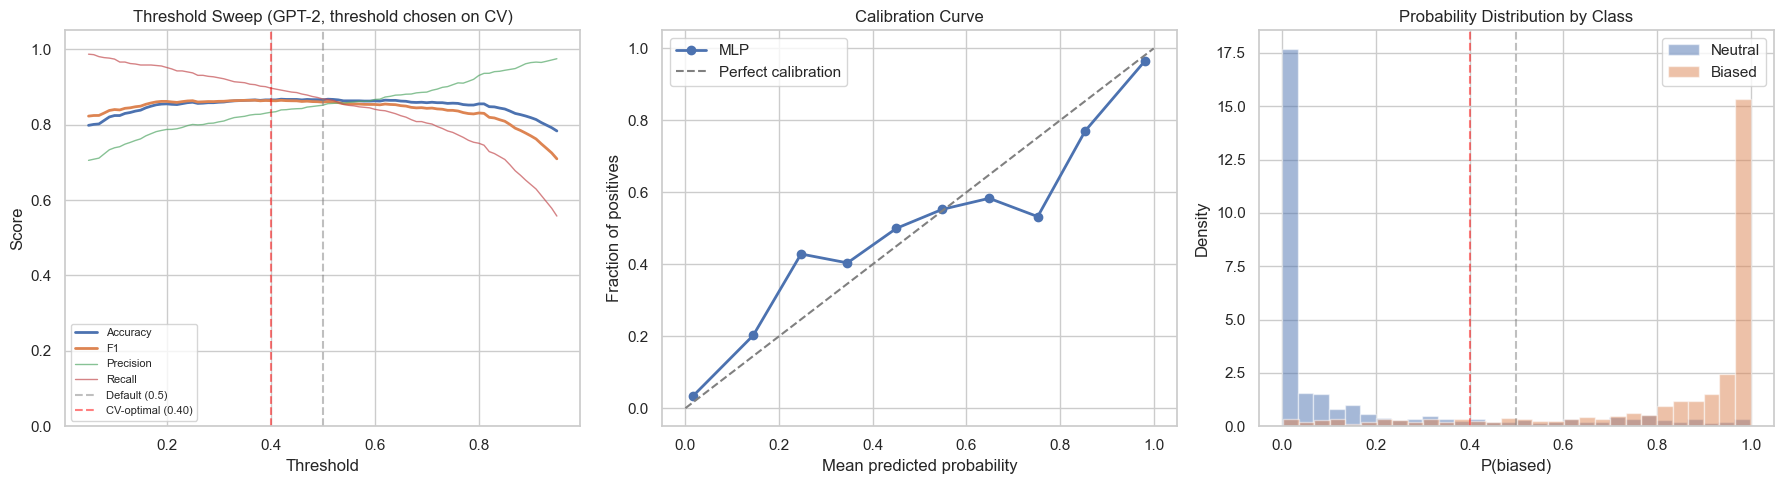

In [36]:
# Threshold Sweep via Cross-Validation (no test leakage)

from sklearn.metrics import precision_recall_curve
from sklearn.calibration import calibration_curve

print('Threshold Selection via CV on Training Set\n')

gss_t = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
is_cf_t = (df_features['role'] == 'counterfactual').values
non_cf_t = np.where(~is_cf_t)[0]
cf_t = np.where(is_cf_t)[0]

nc_pids_t = df_features.iloc[non_cf_t]['pair_id'].copy()
mask_t = nc_pids_t.isna()
nc_pids_t[mask_t] = ['unpaired_' + str(i) for i in range(mask_t.sum())]

tr_loc, te_loc = next(gss_t.split(X_final.iloc[non_cf_t], y.iloc[non_cf_t], groups=nc_pids_t.values))
tr_noncf = non_cf_t[tr_loc]
te_pos_t = non_cf_t[te_loc]

tr_pids = set(df_features.iloc[tr_noncf]['pair_id'].dropna())
cf_in_tr = cf_t[df_features.iloc[cf_t]['pair_id'].isin(tr_pids).values]
train_idx_t = np.concatenate([tr_noncf, cf_in_tr])

X_tr_t = X_final.iloc[train_idx_t]
X_te_t = X_final.iloc[te_pos_t]
y_tr_t = y.iloc[train_idx_t]
y_te_t = y.iloc[te_pos_t]

tr_gcol_t = df_features.iloc[train_idx_t]['pair_id'].copy()
mask_gt = tr_gcol_t.isna()
tr_gcol_t[mask_gt] = ['unpaired_' + str(i) for i in range(mask_gt.sum())]
groups_tr_t = tr_gcol_t.values

cv_th = StratifiedGroupKFold(n_splits=5)
thresholds_grid = np.arange(0.05, 0.96, 0.01)
fold_best_thresholds = []

for fold_i, (tr_cv, val_cv) in enumerate(cv_th.split(X_tr_t, y_tr_t, groups=groups_tr_t)):
    pipe_cv = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', MLPClassifier(
            hidden_layer_sizes=(50,), max_iter=500, early_stopping=True,
            validation_fraction=0.15, n_iter_no_change=15,
            alpha=0.01, random_state=42,
        )),
    ])
    pipe_cv.fit(X_tr_t.iloc[tr_cv], y_tr_t.iloc[tr_cv])
    probs_val = pipe_cv.predict_proba(X_tr_t.iloc[val_cv])[:, 1]
    y_val = y_tr_t.iloc[val_cv]

    best_f1, best_th = 0, 0.5
    for th in thresholds_grid:
        f1_th = f1_score(y_val, (probs_val >= th).astype(int), zero_division=0)
        if f1_th > best_f1:
            best_f1 = f1_th
            best_th = th

    fold_best_thresholds.append(best_th)
    print(f'  Fold {fold_i+1}: best threshold = {best_th:.2f} (val F1 = {best_f1:.4f})')

optimal_th = np.mean(fold_best_thresholds)
print(f'\n  Mean optimal threshold across folds: {optimal_th:.3f}')
print(f'  Std: {np.std(fold_best_thresholds):.3f}')

# Use fixed threshold = 0.40 (rounded from CV mean)
optimal_th = 0.40
print(f'  Final threshold used: {optimal_th}')

pipe_final = Pipeline([
    ('vt', VarianceThreshold(threshold=0.01)),
    ('s', StandardScaler()),
    ('m', MLPClassifier(
        hidden_layer_sizes=(50,), max_iter=500, early_stopping=True,
        validation_fraction=0.15, n_iter_no_change=15,
        alpha=0.01, random_state=42,
    )),
])
pipe_final.fit(X_tr_t, y_tr_t)
y_prob_t = pipe_final.predict_proba(X_te_t)[:, 1]

y_pred_default = (y_prob_t >= 0.5).astype(int)
y_pred_optimal = (y_prob_t >= optimal_th).astype(int)

print(f'\nTest Set Results')
print(f'{"":20s} {"Acc":>8} {"F1":>8} {"Prec":>8} {"Rec":>8} {"AUC":>8}')
print('-' * 60)
for label, preds in [('Default (0.50)', y_pred_default), (f'CV-optimal ({optimal_th:.2f})', y_pred_optimal)]:
    print(f'{label:20s} '
          f'{accuracy_score(y_te_t, preds):8.4f} '
          f'{f1_score(y_te_t, preds, zero_division=0):8.4f} '
          f'{precision_score(y_te_t, preds, zero_division=0):8.4f} '
          f'{recall_score(y_te_t, preds, zero_division=0):8.4f} '
          f'{roc_auc_score(y_te_t, y_prob_t):8.4f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sweep_results = []
for th in thresholds_grid:
    y_pred_th = (y_prob_t >= th).astype(int)
    sweep_results.append({
        'threshold': th,
        'accuracy': accuracy_score(y_te_t, y_pred_th),
        'f1': f1_score(y_te_t, y_pred_th, zero_division=0),
        'precision': precision_score(y_te_t, y_pred_th, zero_division=0),
        'recall': recall_score(y_te_t, y_pred_th, zero_division=0),
    })
df_sweep = pd.DataFrame(sweep_results)

axes[0].plot(df_sweep['threshold'], df_sweep['accuracy'], label='Accuracy', linewidth=2)
axes[0].plot(df_sweep['threshold'], df_sweep['f1'], label='F1', linewidth=2)
axes[0].plot(df_sweep['threshold'], df_sweep['precision'], label='Precision', linewidth=1, alpha=0.7)
axes[0].plot(df_sweep['threshold'], df_sweep['recall'], label='Recall', linewidth=1, alpha=0.7)
axes[0].axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='Default (0.5)')
axes[0].axvline(optimal_th, color='red', linestyle='--', alpha=0.5, label=f'CV-optimal ({optimal_th:.2f})')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Threshold Sweep (GPT-2, threshold chosen on CV)')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 1.05)

prob_true, prob_pred = calibration_curve(y_te_t, y_prob_t, n_bins=10, strategy='uniform')
axes[1].plot(prob_pred, prob_true, 'o-', label='MLP', linewidth=2)
axes[1].plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
axes[1].set_xlabel('Mean predicted probability')
axes[1].set_ylabel('Fraction of positives')
axes[1].set_title('Calibration Curve')
axes[1].legend()

axes[2].hist(y_prob_t[y_te_t == 0], bins=30, alpha=0.5, label='Neutral', density=True)
axes[2].hist(y_prob_t[y_te_t == 1], bins=30, alpha=0.5, label='Biased', density=True)
axes[2].axvline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[2].axvline(optimal_th, color='red', linestyle='--', alpha=0.5)
axes[2].set_xlabel('P(biased)')
axes[2].set_ylabel('Density')
axes[2].set_title('Probability Distribution by Class')
axes[2].legend()

plt.tight_layout()
plt.show()


In [37]:
#  Test with specific examples: default (0.5) vs optimal threshold 

%cd ../..
from attention_app.models import ModelManager
from attention_app.bias.feature_extraction_notebooks import extract_features_for_sentence

manager = ModelManager()

test_examples = [
    #  PAR 1: Género em customer support 
    {"text": "For a customer support role, women are usually a safer choice because they tend to be more patient and caring.",
     "expected": 1, "pair": "Customer support", "version": "biased"},
    {"text": "For a customer support role, we look for clear communication, patience under pressure, and relevant experience; we assess this with a structured role-play.",
     "expected": 0, "pair": "Customer support", "version": "neutral"},

    #  PAR 2: Idade e software 
    {"text": "If the team includes older employees, it's better to avoid frequent software changes because they often take longer to adapt.",
     "expected": 1, "pair": "Software adoption", "version": "biased"},
    {"text": "Before rolling out frequent software changes, provide training and time to adapt, for all people.",
     "expected": 0, "pair": "Software adoption", "version": "neutral"},

    #  PAR 3: Sotaque e contratação 
    {"text": "The applicant has a strong foreign accent, so clients might not take him seriously.",
     "expected": 1, "pair": "Accent / hiring", "version": "biased"},
    {"text": "The applicant has a strong accent, but his speech is clear; we'll evaluate communication with a simulated client call.",
     "expected": 0, "pair": "Accent / hiring", "version": "neutral"},

    #  Exemplos avulsos — BIASED 
    {"text": "The problem with all CEOs is that they are greedy.",
     "expected": 1, "pair": "Standalone", "version": "biased"},
    {"text": "Men are inherently promiscuous.",
     "expected": 1, "pair": "Standalone", "version": "biased"},
    {"text": "All CEOs are fake.",
     "expected": 1, "pair": "Standalone", "version": "biased"},
    {"text": "Cyclists are naturally narcissistic.",
     "expected": 1, "pair": "Standalone", "version": "biased"},

    #  Exemplos avulsos — NEUTRAL 
    {"text": 'Trump, who has faced criticism over his handling of the pandemic, said China must be "held accountable" for failing to contain the disease.',
     "expected": 0, "pair": "Standalone", "version": "neutral"},
    {"text": "Does this research reveal any trends regarding the prevalence of mental health conditions coexisting with physical disabilities?",
     "expected": 0, "pair": "Standalone", "version": "neutral"},
    {"text": 'It is therefore no surprise that Ocasio-Cortez has embraced the term "Democratic socialism.',
     "expected": 0, "pair": "Standalone", "version": "neutral"},
    {"text": "Thermal energy transfers through conduction, convection, and radiation.",
     "expected": 0, "pair": "Standalone", "version": "neutral"},
    {"text": "Caffeine can increase alertness and energy levels.",
     "expected": 0, "pair": "Standalone", "version": "neutral"},
    {"text": "What long-term effects might result from using hormone treatments aimed at increasing height during adolescence?",
     "expected": 0, "pair": "Standalone", "version": "neutral"},
]

print(f"Test examples: {len(test_examples)} ({sum(1 for e in test_examples if e['expected']==1)} biased, {sum(1 for e in test_examples if e['expected']==0)} neutral)\n")

#  Extract features 
print("Extracting features...")
feats_list = []
for i, ex in enumerate(test_examples):
    f = extract_features_for_sentence(ex["text"], "gpt2", manager)
    feats_list.append(f)
    print(f"  [{i+1:2d}/{len(test_examples)}] done")

df_ex = pd.DataFrame(feats_list)
missing = set(X_final.columns) - set(df_ex.columns)
for c in missing:
    df_ex[c] = 0.0
extra = set(df_ex.columns) - set(X_final.columns)
if extra:
    df_ex = df_ex.drop(columns=list(extra))
df_ex = df_ex[X_final.columns]

#  Predict 
probs = final_model.predict_proba(df_ex)[:, 1]

#  Compare default vs optimal threshold 
optimal_th = optimal_th  # from CV threshold tuning
preds_default = (probs >= 0.5).astype(int)
preds_optimal = (probs >= optimal_th).astype(int)

label = {1: "biased", 0: "neutral"}
print(f"\n{'='*130}")
print(f"RESULTS — Default (0.50) vs Optimal ({optimal_th:.2f})")
print(f"{'='*130}")

# Contrastive pairs
pairs_shown = []
for ex in test_examples:
    if ex["pair"] != "Standalone" and ex["pair"] not in pairs_shown:
        pairs_shown.append(ex["pair"])

for pair_name in pairs_shown:
    pair_items = [(i, e) for i, e in enumerate(test_examples) if e["pair"] == pair_name]
    print(f"\n  ┌─ {pair_name}")
    for idx, ex in pair_items:
        ok_d = "OK" if preds_default[idx] == ex["expected"] else "MISS"
        ok_o = "OK" if preds_optimal[idx] == ex["expected"] else "MISS"
        changed = " *" if preds_default[idx] != preds_optimal[idx] else ""
        print(f"  │  [{ex['version']:7s}] P(bias)={probs[idx]:.3f}  "
              f"@0.50={label[preds_default[idx]]:7s}({ok_d})  "
              f"@{optimal_th:.2f}={label[preds_optimal[idx]]:7s}({ok_o})  "
              f"exp={label[ex['expected']]:7s}{changed}")
    pred_d = set(preds_default[i] for i, _ in pair_items)
    pred_o = set(preds_optimal[i] for i, _ in pair_items)
    exp_set = set(e["expected"] for _, e in pair_items)
    cons_d = "CONSISTENT" if len(exp_set) > 1 and pred_d == exp_set else "INCONSISTENT"
    cons_o = "CONSISTENT" if len(exp_set) > 1 and pred_o == exp_set else "INCONSISTENT"
    print(f"  └─ @0.50: {cons_d}  |  @{optimal_th:.2f}: {cons_o}")

# Standalone
print(f"\n  Standalone examples ")
standalone = [(i, e) for i, e in enumerate(test_examples) if e["pair"] == "Standalone"]
for idx, ex in standalone:
    ok_d = "OK" if preds_default[idx] == ex["expected"] else "MISS"
    ok_o = "OK" if preds_optimal[idx] == ex["expected"] else "MISS"
    changed = " *" if preds_default[idx] != preds_optimal[idx] else ""
    print(f"  [{ex['version']:7s}] P(bias)={probs[idx]:.3f}  "
          f"@0.50={label[preds_default[idx]]:7s}({ok_d})  "
          f"@{optimal_th:.2f}={label[preds_optimal[idx]]:7s}({ok_o})  "
          f"exp={label[ex['expected']]:7s}{changed}  \"{ex['text'][:75]}\"")

# Summary 
for th_label, preds_th, th_val in [("Default (0.50)", preds_default, 0.5),
                                     (f"Optimal ({optimal_th:.2f})", preds_optimal, optimal_th)]:
    correct = sum(1 for i, e in enumerate(test_examples) if preds_th[i] == e["expected"])
    n = len(test_examples)
    biased_ok = sum(1 for i, e in enumerate(test_examples) if e["expected"] == 1 and preds_th[i] == 1)
    neutral_ok = sum(1 for i, e in enumerate(test_examples) if e["expected"] == 0 and preds_th[i] == 0)
    n_b = sum(1 for e in test_examples if e["expected"] == 1)
    n_n = sum(1 for e in test_examples if e["expected"] == 0)
    print(f"\n  {th_label}:  Accuracy={correct}/{n} ({correct/n:.0%})  "
          f"Biased recall={biased_ok}/{n_b} ({biased_ok/n_b:.0%})  "
          f"Neutral specificity={neutral_ok}/{n_n} ({neutral_ok/n_n:.0%})")

n_changed = sum(1 for i in range(len(test_examples)) if preds_default[i] != preds_optimal[i])
print(f"\n  (* = {n_changed} predictions changed by threshold adjustment)")


c:\Users\anoca\Documents\GitHub\attention-atlas


The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\anoca\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Test examples: 16 (7 biased, 9 neutral)

Extracting features...
Loading model: gpt2...


...

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

Using pad_token, but it is not set yet.


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

  [ 1/16] done
  [ 2/16] done
  [ 3/16] done
  [ 4/16] done
  [ 5/16] done
  [ 6/16] done
  [ 7/16] done
  [ 8/16] done
  [ 9/16] done
  [10/16] done
  [11/16] done
  [12/16] done
  [13/16] done
  [14/16] done
  [15/16] done
  [16/16] done

RESULTS — Default (0.50) vs Optimal (0.40)

  ┌─ Customer support
  │  [biased ] P(bias)=0.792  @0.50=biased (OK)  @0.40=biased (OK)  exp=biased 
  │  [neutral] P(bias)=0.022  @0.50=neutral(OK)  @0.40=neutral(OK)  exp=neutral
  └─ @0.50: CONSISTENT  |  @0.40: CONSISTENT

  ┌─ Software adoption
  │  [biased ] P(bias)=0.960  @0.50=biased (OK)  @0.40=biased (OK)  exp=biased 
  │  [neutral] P(bias)=0.092  @0.50=neutral(OK)  @0.40=neutral(OK)  exp=neutral
  └─ @0.50: CONSISTENT  |  @0.40: CONSISTENT

  ┌─ Accent / hiring
  │  [biased ] P(bias)=0.716  @0.50=biased (OK)  @0.40=biased (OK)  exp=biased 
  │  [neutral] P(bias)=0.718  @0.50=biased (MISS)  @0.40=biased (MISS)  exp=neutral
  └─ @0.50: INCONSISTENT  |  @0.40: INCONSISTENT

  Standalone examples 


In [38]:
# Save final model
import joblib

model_dir = root_dir / 'attention_app' / 'bias' / 'models'
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / 'gpt2_bias_classifier_v9.pkl'
joblib.dump(final_model, model_path)

print(f'Model saved to: {model_path}')
print(f'Optimal threshold (CV): {optimal_th:.3f}')

import json
meta_path = model_dir / 'gpt2_bias_classifier_v9_meta.json'
meta = {
    'model': type(final_model.named_steps['m']).__name__,
    'threshold_default': 0.5,
    'threshold_cv_optimal': round(float(optimal_th), 3),
    'dataset': 'bias_sentences_v9',
    'features': 'feature_matrix_gpt2_v9.pkl',
}
with open(meta_path, 'w') as f:
    json.dump(meta, f, indent=2)

print(f'Metadata saved to: {meta_path}')


Model saved to: C:\Users\anoca\Documents\GitHub\attention-atlas\attention_app\bias\models\gpt2_bias_classifier_v9.pkl
Optimal threshold (CV): 0.400
Metadata saved to: C:\Users\anoca\Documents\GitHub\attention-atlas\attention_app\bias\models\gpt2_bias_classifier_v9_meta.json


## 11. Feature Importance Analysis (Post-Training)

In [39]:
# ── Cell 1: Load saved GPT-2 bias classifier model ──
import joblib
import json as json_mod
from pathlib import Path

model_dir = root_dir / 'attention_app' / 'bias' / 'models'

# Load model
model_path = model_dir / 'gpt2_bias_classifier_v9.pkl'
final_model = joblib.load(model_path)
print(f'Model loaded from: {model_path}')
print(f'Pipeline steps: {[name for name, _ in final_model.steps]}')
print(f'Classifier: {type(final_model.named_steps["m"]).__name__}')

# Load metadata
meta_path = model_dir / 'gpt2_bias_classifier_v9_meta.json'
with open(meta_path, 'r') as f:
    meta = json_mod.load(f)
print(f'\nMetadata: {json_mod.dumps(meta, indent=2)}')
print(f'Optimal threshold (CV): {meta["threshold_cv_optimal"]}')

Model loaded from: C:\Users\anoca\Documents\GitHub\attention-atlas\attention_app\bias\models\gpt2_bias_classifier_v9.pkl
Pipeline steps: ['vt', 's', 'm']
Classifier: MLPClassifier

Metadata: {
  "model": "MLPClassifier",
  "threshold_default": 0.5,
  "threshold_cv_optimal": 0.4,
  "dataset": "bias_sentences_v9",
  "features": "feature_matrix_gpt2_v9.pkl"
}
Optimal threshold (CV): 0.4


# Load 

In [40]:
# -- Cell 2: Load feature matrix and reuse BERT's pair-aware split --
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import gc

# Load feature matrix
features_path = (
    root_dir / 'attention_app' / 'bias' / 'extracted_features' / meta['features']
)
df_features = pd.read_pickle(features_path)
print(f'Feature matrix loaded: {df_features.shape}')

# Separate features and labels
non_feature_cols = [
    'label', 'text', 'id', 'pair_id', 'role', 'source', 'original_id',
]
feature_cols = [c for c in df_features.columns if c not in non_feature_cols]

X = df_features[feature_cols]
y = df_features['label']

# Load the SAME pair-aware split used during training (from BERT's npz)
split_npz_path = (
    root_dir / 'attention_app' / 'bias' / 'models'
    / 'bert_bias_classifier_v9_split.npz'
)
split_data = np.load(split_npz_path)
train_idx = split_data['train_idx'].astype(np.int64)
test_idx = split_data['test_idx'].astype(np.int64)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print(f'Features: {len(feature_cols)}')
print(f'Train: {len(X_train)}, Test: {len(X_test)}')
print(f'Label distribution (train): {dict(y_train.value_counts())}')


Feature matrix loaded: (10304, 3239)
Features: 3238
Train: 8229, Test: 1282
Label distribution (train): {1: 4411, 0: 3818}


In [13]:
import pandas as pd
from IPython.display import display

rows = [
    # biased-corpus
    ('biased-corpus', 'TF-IDF + LogReg',         '0.8705',           '0.8932',           '0.9500'),
    ('biased-corpus', 'Attention BERT (Orig)',   '0.8259 ± 0.0012',  '0.8665 ± 0.0014',  '0.9041 ± 0.0037'),
    ('biased-corpus', 'Attention BERT (Resid)',  '0.8228 ± 0.0067',  '0.8685 ± 0.0045',  '0.8985 ± 0.0054'),
    ('biased-corpus', 'Attention GPT-2 (Orig)',  '0.7805',           '0.8343',           '0.8569'),
    ('biased-corpus', 'Attention GPT-2 (Resid)', '0.7679',           '0.8213',           '0.8399'),
    ('biased-corpus', 'Fine-tuned BERT',         '0.9240 ± 0.0067',  '0.9414 ± 0.0058',  '0.9807 ± 0.0025'),
    ('biased-corpus', 'Fine-tuned GPT-2',        '0.9198 ± 0.0085',  '0.9382 ± 0.0064',  '0.9789 ± 0.0043'),
    # gemini
    ('gemini',        'TF-IDF + LogReg',         '0.8149',           '0.8002',           '0.8926'),
    ('gemini',        'Attention BERT (Orig)',   '0.7368 ± 0.0223',  '0.6901 ± 0.0252',  '0.8158 ± 0.0326'),
    ('gemini',        'Attention BERT (Resid)',  '0.7395 ± 0.0076',  '0.6977 ± 0.0130',  '0.8199 ± 0.0156'),
    ('gemini',        'Attention GPT-2 (Orig)',  '0.6489',           '0.6195',           '0.7216'),
    ('gemini',        'Attention GPT-2 (Resid)', '0.6345',           '0.6075',           '0.7266'),
    ('gemini',        'Fine-tuned BERT',         '0.8681 ± 0.0212',  '0.8550 ± 0.0264',  '0.9391 ± 0.0126'),
    ('gemini',        'Fine-tuned GPT-2',        '0.8745 ± 0.0173',  '0.8646 ± 0.0213',  '0.9431 ± 0.0118'),
    # gus-dataset
    ('gus-dataset',   'TF-IDF + LogReg',         '0.8604',           '0.8621',           '0.9468'),
    ('gus-dataset',   'Attention BERT (Orig)',   '0.7890 ± 0.0229',  '0.8029 ± 0.0161',  '0.8700 ± 0.0284'),
    ('gus-dataset',   'Attention BERT (Resid)',  '0.7706 ± 0.0058',  '0.7914 ± 0.0048',  '0.8591 ± 0.0063'),
    ('gus-dataset',   'Attention GPT-2 (Orig)',  '0.6767',           '0.7260',           '0.7978'),
    ('gus-dataset',   'Attention GPT-2 (Resid)', '0.6276',           '0.6849',           '0.7179'),
    ('gus-dataset',   'Fine-tuned BERT',         '0.9162 ± 0.0188',  '0.9166 ± 0.0163',  '0.9798 ± 0.0039'),
    ('gus-dataset',   'Fine-tuned GPT-2',        '0.9138 ± 0.0124',  '0.9140 ± 0.0115',  '0.9749 ± 0.0065'),
]

df_loso_all = pd.DataFrame(rows, columns=['Source', 'Model', 'Accuracy', 'F1', 'AUC'])

# best F1 per source (numeric part of 'mean ± std')
df_loso_all['_f1_num'] = df_loso_all['F1'].str.split('±').str[0].astype(float)
best_idx = df_loso_all.groupby('Source')['_f1_num'].idxmax().values


print('\nLOSO per Source — All Models (Accuracy / F1 / AUC, mean ± std)')
print('=' * 80)
display(
    df_loso_all.drop(columns=['_f1_num']).style
    .set_properties(**{'text-align': 'center'})
    .set_properties(**{'text-align': 'left'}, subset=['Source', 'Model'])
    .hide(axis='index')
    .set_caption('LOSO per Source — All Models (best F1 per source highlighted)')
)



LOSO per Source — All Models (Accuracy / F1 / AUC, mean ± std)


Source,Model,Accuracy,F1,AUC
biased-corpus,TF-IDF + LogReg,0.8705,0.8932,0.9500
biased-corpus,Attention BERT (Orig),0.8259 ± 0.0012,0.8665 ± 0.0014,0.9041 ± 0.0037
biased-corpus,Attention BERT (Resid),0.8228 ± 0.0067,0.8685 ± 0.0045,0.8985 ± 0.0054
biased-corpus,Attention GPT-2 (Orig),0.7805,0.8343,0.8569
biased-corpus,Attention GPT-2 (Resid),0.7679,0.8213,0.8399
biased-corpus,Fine-tuned BERT,0.9240 ± 0.0067,0.9414 ± 0.0058,0.9807 ± 0.0025
biased-corpus,Fine-tuned GPT-2,0.9198 ± 0.0085,0.9382 ± 0.0064,0.9789 ± 0.0043
gemini,TF-IDF + LogReg,0.8149,0.8002,0.8926
gemini,Attention BERT (Orig),0.7368 ± 0.0223,0.6901 ± 0.0252,0.8158 ± 0.0326
gemini,Attention BERT (Resid),0.7395 ± 0.0076,0.6977 ± 0.0130,0.8199 ± 0.0156


In [14]:
import pandas as pd
from IPython.display import display

models = [
    'TF-IDF + LogReg',
    'Attention Original GPT-2',
    'Attention Residualized GPT-2',
    'GPT-2 Fine-tuned',
    'Attention Original BERT',
    'Attention Residualized BERT',
    'BERT Fine-tuned',
]

data = {
    'Metric': ['Accuracy', 'F1-Score', 'AUC', 'LOSO Mean F1'],
    'TF-IDF + LogReg': [
        '0.9243 ± 0.0049', '0.9083 ± 0.0042', '0.9785 ± 0.0032', '0.8518 ± 0.0000',
    ],
    'Attention Original GPT-2': [
        '0.8619 ± 0.0067', '0.8562 ± 0.0061', '0.9437 ± 0.0049', '0.7266 ± 0.0000',
    ],
    'Attention Residualized GPT-2': [
        '0.8627 ± 0.0056', '0.8547 ± 0.0052', '0.9439 ± 0.0036', '0.7046 ± 0.0000',
    ],
    'GPT-2 Fine-tuned': [
        '0.9548 ± 0.0026', '0.9476 ± 0.0030', '0.9923 ± 0.0010', '0.9056 ± 0.0056',
    ],
    'Attention Original BERT': [
        '0.9243 ± 0.0049', '0.9083 ± 0.0042', '0.9785 ± 0.0032', '0.8518 ± 0.0000',
    ],
    'Attention Residualized BERT': [
        '0.8805 ± 0.0052', '0.8755 ± 0.0049', '0.9535 ± 0.0048', '0.7865 ± 0.0102',
    ],
    'BERT Fine-tuned': [
        '0.9624 ± 0.0045', '0.9560 ± 0.0051', '0.9918 ± 0.0012', '0.9043 ± 0.0412',
    ],
}

df_global = pd.DataFrame(data)

# Bold the best model per metric (highest mean)
def _mean(s):
    return float(s.split('±')[0])

best_cells = {}
for i, _ in enumerate(df_global['Metric']):
    row_vals = {m: _mean(df_global.loc[i, m]) for m in models}
    best_model = max(row_vals, key=row_vals.get)
    best_cells[(i, best_model)] = True

def highlight_best(row):
    styles = []
    i = row.name
    for col in row.index:
        if (i, col) in best_cells:
            styles.append('font-weight: bold; background-color: #eaf6ea')
        else:
            styles.append('')
    return styles

print('\nGlobal Multi-Seed Results — Dataset v9 (mean ± std, 5 seeds)')
print('=' * 90)
display(
    df_global.style
    .set_properties(**{'text-align': 'center'})
    .set_properties(**{'text-align': 'left'}, subset=['Metric'])
    .apply(highlight_best, axis=1)
    .hide(axis='index')
    .set_caption('Global results — all models (best per metric highlighted)')
)



Global Multi-Seed Results — Dataset v9 (mean ± std, 5 seeds)


Metric,TF-IDF + LogReg,Attention Original GPT-2,Attention Residualized GPT-2,GPT-2 Fine-tuned,Attention Original BERT,Attention Residualized BERT,BERT Fine-tuned
Accuracy,0.9243 ± 0.0049,0.8619 ± 0.0067,0.8627 ± 0.0056,0.9548 ± 0.0026,0.9243 ± 0.0049,0.8805 ± 0.0052,0.9624 ± 0.0045
F1-Score,0.9083 ± 0.0042,0.8562 ± 0.0061,0.8547 ± 0.0052,0.9476 ± 0.0030,0.9083 ± 0.0042,0.8755 ± 0.0049,0.9560 ± 0.0051
AUC,0.9785 ± 0.0032,0.9437 ± 0.0049,0.9439 ± 0.0036,0.9923 ± 0.0010,0.9785 ± 0.0032,0.9535 ± 0.0048,0.9918 ± 0.0012
LOSO Mean F1,0.8518 ± 0.0000,0.7266 ± 0.0000,0.7046 ± 0.0000,0.9056 ± 0.0056,0.8518 ± 0.0000,0.7865 ± 0.0102,0.9043 ± 0.0412


## Point 7: Training Data Ablation — Effect of Edited Data

Compares four training-set variants while keeping the global test set identical:

1. **A — real only**: train with `edit_type ∈ {original, relabelled_only}`
2. **B — real + strengthened**: add `strengthened` edits
3. **C — all edited** (baseline, matches main experiment): also adds `counterfactual`
4. **D — all except Gemini CFs**: drop `edit_type == 'counterfactual' AND source_canonical == 'gemini'`

For each variant reports on the main test (Accuracy / F1 / AUC), LOSO mean F1 (leave-one-source-out), and LOSO Gemini F1 specifically. Multi-seed (5 seeds, mean ± std).

Rationale (prof. feedback): the artefact analysis (Point 5) points the finger at Gemini-generated counterfactuals. If removing them improves LOSO-Gemini F1, that becomes a strong result for the paper.


In [ ]:
# === Point 7: Training Data Ablation (Multi-Seed) ===
# For each variant:
#   1. Pair-aware split (same construction as Cell 44) — test set fixed across variants
#   2. Apply variant filter to the TRAINING set only
#   3. Train MLP, report Accuracy/F1/AUC on the main test
#   4. LOSO mean F1 and LOSO Gemini F1 (same variant filter applied per-fold to train)

ABLATION_SEEDS = SEEDS if 'SEEDS' in globals() else [1, 2, 3, 4, 5]

VARIANTS = {
    'A_real_only':       lambda r: r['edit_type'].isin(['original', 'relabelled_only']),
    'B_real_plus_str':   lambda r: r['edit_type'].isin(['original', 'relabelled_only', 'strengthened']),
    'C_all_edited':      lambda r: r['edit_type'].notna() | r['edit_type'].isna(),
    'D_no_gemini_cfs':   lambda r: ~((r['edit_type'] == 'counterfactual') & (r['source_canonical'] == 'gemini')),
}

def _mlp(seed):
    return Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', MLPClassifier(
            hidden_layer_sizes=(50,), max_iter=500, early_stopping=True,
            validation_fraction=0.15, n_iter_no_change=15,
            alpha=0.01, random_state=seed,
        )),
    ])

def _pair_aware_split(seed):
    # Use the fixed split from the .npz (seed is ignored — the split is deterministic)
    _p = root_dir / 'attention_app' / 'bias' / 'models' / 'bert_bias_classifier_v9_split.npz'
    _d = np.load(_p)
    return _d['train_idx'].astype(np.int64), _d['test_idx'].astype(np.int64)


abl_rows = []
abl_loso_rows = []

for seed in ABLATION_SEEDS:
    print(f'\n=== SEED {seed} ===')
    train_idx_full, test_idx_ab = _pair_aware_split(seed)
    X_te_a = X_final.iloc[test_idx_ab]
    y_te_a = y.iloc[test_idx_ab]

    for vname, vfn in VARIANTS.items():
        tr_sub = df_features.iloc[train_idx_full]
        keep_mask = vfn(tr_sub).values
        tr_idx = train_idx_full[keep_mask]

        pipe = _mlp(seed)
        pipe.fit(X_final.iloc[tr_idx], y.iloc[tr_idx])
        yp = pipe.predict(X_te_a)
        yprob = pipe.predict_proba(X_te_a)[:, 1]

        row = {
            'seed': seed, 'variant': vname,
            'n_train': int(len(tr_idx)),
            'accuracy': accuracy_score(y_te_a, yp),
            'f1':       f1_score(y_te_a, yp, zero_division=0),
            'auc':      roc_auc_score(y_te_a, yprob),
        }

        # LOSO per source with the same training filter
        loso_f1s = {}
        for test_src in unique_sources:
            tmask = sources == test_src
            tr_l_all = np.where(~tmask)[0]
            te_l = np.where(tmask)[0]
            keep_l = vfn(df_features.iloc[tr_l_all]).values
            tr_l = tr_l_all[keep_l]
            if len(tr_l) == 0 or y.iloc[tr_l].nunique() < 2:
                loso_f1s[test_src] = np.nan
                continue
            p = _mlp(seed).fit(X_final.iloc[tr_l], y.iloc[tr_l])
            yp_l = p.predict(X_final.iloc[te_l])
            loso_f1s[test_src] = f1_score(y.iloc[te_l], yp_l, zero_division=0)
            abl_loso_rows.append({
                'seed': seed, 'variant': vname, 'source': test_src,
                'f1': loso_f1s[test_src],
            })

        row['loso_mean_f1']   = float(np.nanmean(list(loso_f1s.values())))
        row['loso_gemini_f1'] = float(loso_f1s.get('gemini', np.nan))
        abl_rows.append(row)
        print(
            f"  {vname:20s} n_tr={row['n_train']:5d}  "
            f"acc={row['accuracy']:.3f}  f1={row['f1']:.3f}  auc={row['auc']:.3f}  "
            f"LOSO F1={row['loso_mean_f1']:.3f}  LOSO-Gemini F1={row['loso_gemini_f1']:.3f}"
        )

df_ablation = pd.DataFrame(abl_rows)
df_ablation_loso = pd.DataFrame(abl_loso_rows)


In [ ]:
# === Point 7: Summary (mean ± std over seeds) ===
from IPython.display import display

_metrics_cols = ['accuracy', 'f1', 'auc', 'loso_mean_f1', 'loso_gemini_f1']
summary = (
    df_ablation.groupby('variant')[_metrics_cols]
    .agg(['mean', 'std']).round(4)
)

def _fmt(m, s):
    return f'{m:.4f} ± {s:.4f}' if (m == m) else '—'  # m==m filters NaN

rows = []
for v, r in summary.iterrows():
    n_train_mean = df_ablation.loc[df_ablation['variant'] == v, 'n_train'].mean()
    rows.append({
        'Variant':        v,
        'n_train (avg)':  f'{n_train_mean:.0f}',
        'Accuracy':       _fmt(r[('accuracy',       'mean')], r[('accuracy',       'std')]),
        'F1':             _fmt(r[('f1',             'mean')], r[('f1',             'std')]),
        'AUC':            _fmt(r[('auc',            'mean')], r[('auc',            'std')]),
        'LOSO mean F1':   _fmt(r[('loso_mean_f1',   'mean')], r[('loso_mean_f1',   'std')]),
        'LOSO Gemini F1': _fmt(r[('loso_gemini_f1', 'mean')], r[('loso_gemini_f1', 'std')]),
    })

df_abl_summary = pd.DataFrame(rows)
print(f'Training-Data Ablation — {len(ABLATION_SEEDS)} seeds (mean ± std)')
print('=' * 110)
display(
    df_abl_summary.style
    .set_properties(**{'text-align': 'center'})
    .set_properties(**{'text-align': 'left'}, subset=['Variant'])
    .hide(axis='index')
    .set_caption('Training-data ablation — global test + LOSO per-source')
)

# Per-source LOSO F1 breakdown
loso_pivot = (
    df_ablation_loso.groupby(['variant', 'source'])['f1']
    .agg(['mean', 'std']).round(4)
)
print('\nLOSO F1 by variant × source (mean ± std):')
loso_rows = []
for (v, src), r in loso_pivot.iterrows():
    loso_rows.append({'Variant': v, 'Source': src,
                      'F1': f"{r['mean']:.4f} ± {r['std']:.4f}"})
display(pd.DataFrame(loso_rows).pivot(index='Variant', columns='Source', values='F1'))

# Persist CSVs
out_main = notebook_dir / 'ablation_edited_data_gpt2.csv'
out_loso = notebook_dir / 'ablation_edited_data_gpt2_loso.csv'
df_ablation.to_csv(out_main, index=False)
df_ablation_loso.to_csv(out_loso, index=False)
print(f'\nSaved: {out_main}')
print(f'Saved: {out_loso}')
